<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Parsons_Political_System_Experiment_V4_COORDINATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вычислительная модель политической системы Толкотта Парсонса
## V4: функционально-координационный процесс с V3 baseline

V4 сохраняет весь production-ready контур V3 и добавляет адаптивный слой:

\[
\text{Parsons Functional Coordination Process (PFCP)}
\]

PFCP близок к factored Dec-POMDP и CTDE-MARL, но не трактует функции \(A,G,I,L\)
как эгоистических игроков. Четыре функциональных центра:

- имеют частичные локальные наблюдения;
- выбирают локальную интенсивность функционального вклада;
- согласуют совместное действие через coordination graph;
- обучаются по общей системной награде и локальному функциональному вкладу;
- исполняют политику без доступа к полной таблице будущих состояний.

### Сравниваемые архитектуры

1. **V3 fixed-reaction baseline** — 15 реакций и `no_reaction`;
2. **PFCP adaptive coordination** — динамическое совместное действие \(A,G,I,L\);
3. **No-reaction control**.

Данные остаются реальными: 10 стран, 2000–2024 гг., coverage gate 70%.
Тяжёлые траектории не записываются в Excel: в книги включаются только
публикационные агрегаты, а seed-level аудит сохраняется в CSV.GZ.


In [1]:
#@title 0.1. Установка зависимостей
import os, sys, subprocess
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ

REQUIRED_PACKAGES = [
    "pandas", "numpy", "scipy", "scikit-learn", "statsmodels",
    "matplotlib", "xlsxwriter", "tqdm", "nbformat"
]
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES],
        check=True,
    )

In [2]:
#@title 0.2. Импорты, конфигурация и воспроизводимость
import os
import json
import math
import random
import shutil
import hashlib
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if IN_COLAB:
    from tqdm.notebook import tqdm
else:
    from tqdm import tqdm
from scipy import stats
from scipy.special import expit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

@dataclass(frozen=True)
class ExperimentConfig:
    countries: Tuple[str, ...] = (
        "USA", "DEU", "CHN", "IND", "BRA",
        "ZAF", "JPN", "TUR", "RUS", "KAZ",
    )
    start_year: int = 2000
    end_year: int = 2024
    coverage_threshold: float = 0.70

    holdout_start: int = 2022
    development_folds: Tuple[Tuple[int, int, int], ...] = (
        (2009, 2010, 2013),
        (2013, 2014, 2017),
        (2017, 2018, 2021),
    )

    development_ratio_gate: float = 0.98
    development_worst_fold_gate: float = 1.10
    development_country_median_gate: float = 1.05
    holdout_ratio_gate: float = 1.05
    holdout_country_median_gate: float = 1.10
    holdout_country_max_gate: float = 2.00

    n_seeds: int = int(os.getenv("PARSONS_N_SEEDS", "10"))
    robustness_seeds: int = int(os.getenv("PARSONS_ROBUST_SEEDS", "3"))
    horizon: int = int(os.getenv("PARSONS_HORIZON", "10"))

    equilibrium_window: int = 3
    breakdown_window: int = 2
    response_start_step: int = 1
    equilibrium_start_step: int = 2

    shock_scale: float = 0.20
    reaction_scale: float = 0.10
    shock_decay: float = 0.55
    response_ramp: float = 0.80
    response_decay: float = 0.18
    noise_scale: float = 0.010

    # PFCP: shared factorized coordination policy
    pfcp_training_episodes: int = int(os.getenv("PARSONS_PFCP_EPISODES", "1200"))
    pfcp_action_levels: Tuple[float, ...] = (0.0, 0.5, 1.0)
    pfcp_learning_rate: float = 0.12
    pfcp_discount: float = 0.92
    pfcp_epsilon_start: float = 0.30
    pfcp_epsilon_end: float = 0.03
    pfcp_global_reward_weight: float = 0.75
    pfcp_local_reward_weight: float = 0.25
    pfcp_action_cost: float = 0.05
    pfcp_coordination_weight: float = 0.08

    bootstrap_repetitions: int = int(os.getenv("PARSONS_BOOTSTRAPS", "500"))
    random_seed: int = 20260803

    output_dir: str = os.getenv(
        "PARSONS_OUTPUT_DIR",
        "/content/parsons_v4_outputs" if Path("/content").exists() else "./parsons_v4_outputs",
    )

CFG = ExperimentConfig()
AGIL = ("A", "G", "I", "L")
CONTROL = "no_reaction"

OUT = Path(CFG.output_dir)
for folder in ("figures_png", "figures_svg", "tables_csv", "logs", "github"):
    (OUT / folder).mkdir(parents=True, exist_ok=True)

random.seed(CFG.random_seed)
np.random.seed(CFG.random_seed)

print("Конфигурация V3")
display(pd.DataFrame([asdict(CFG)]).T.rename(columns={0: "value"}))

Конфигурация V3


,value
countries,"(USA, DEU, CHN, IND, BRA, ZAF, JPN, TUR, RUS, ..."
start_year,2000
end_year,2024
coverage_threshold,0.7
holdout_start,2022
development_folds,"((2009, 2010, 2013), (2013, 2014, 2017), (2017..."
development_ratio_gate,0.98
development_worst_fold_gate,1.1
development_country_median_gate,1.05
holdout_ratio_gate,1.05


## 1. Онтология и основные индексы

Состояние страны \(c\) в момент \(t\):

\[
\mathbf X_{c,t} = [A_{c,t},G_{c,t},I_{c,t},L_{c,t}]^\top.
\]

Функциональное равновесие:

\[
FE_{c,t}=\left(A_{c,t}G_{c,t}I_{c,t}L_{c,t}\right)^{1/4}.
\]

Bottleneck:

\[
B_{c,t}=\min(A_{c,t},G_{c,t},I_{c,t},L_{c,t}).
\]

Несогласованность:

\[
D_{c,t}=\sqrt{\frac{1}{4}\sum_f(f_{c,t}-\bar f_{c,t})^2}.
\]

Вычислительная мера strain:

\[
S_{c,t}=0.45D_{c,t}+0.30\Delta_{c,t}+0.25(1-Inst_{c,t}).
\]

In [3]:
#@title 1.1. Каталоги онтологии
STRAIN_CLASSES = (
    "adaptive_insufficiency",
    "adaptive_allocation_strain",
    "goal_definition_strain",
    "goal_priority_strain",
    "goal_attainment_strain",
    "mobilization_strain",
    "integrative_coordination_strain",
    "membership_strain",
    "solidarity_strain",
    "pattern_maintenance_strain",
    "motivational_strain",
    "socialization_strain",
    "normative_expectation_strain",
    "legitimation_strain",
    "role_strain",
    "role_conflict_strain",
    "authority_strain",
    "sanction_strain",
    "money_medium_strain",
    "power_medium_strain",
    "influence_medium_strain",
    "value_commitment_strain",
    "interchange_strain",
    "boundary_strain",
)

REACTIONS = (
    "resolution",
    "arrestation",
    "isolation",
    "structural_change",
    "differentiation",
    "adaptive_upgrading",
    "inclusion",
    "value_generalization",
    "institutionalization",
    "legitimation",
    "socialization",
    "social_control",
    "allocation",
    "mobilization",
    "re_specification_of_goals",
)

ARMS = (CONTROL,) + REACTIONS

STRAIN_TARGETS = {
    "adaptive_insufficiency": (1.00, 0.20, 0.10, 0.10),
    "adaptive_allocation_strain": (0.85, 0.35, 0.20, 0.10),
    "goal_definition_strain": (0.15, 1.00, 0.30, 0.20),
    "goal_priority_strain": (0.20, 0.90, 0.45, 0.20),
    "goal_attainment_strain": (0.25, 1.00, 0.25, 0.15),
    "mobilization_strain": (0.40, 0.90, 0.20, 0.15),
    "integrative_coordination_strain": (0.20, 0.35, 1.00, 0.25),
    "membership_strain": (0.10, 0.20, 1.00, 0.40),
    "solidarity_strain": (0.10, 0.20, 0.95, 0.55),
    "pattern_maintenance_strain": (0.10, 0.15, 0.35, 1.00),
    "motivational_strain": (0.15, 0.30, 0.35, 0.90),
    "socialization_strain": (0.10, 0.15, 0.40, 1.00),
    "normative_expectation_strain": (0.10, 0.25, 0.85, 0.65),
    "legitimation_strain": (0.10, 0.50, 0.70, 0.80),
    "role_strain": (0.15, 0.30, 0.85, 0.55),
    "role_conflict_strain": (0.15, 0.35, 0.95, 0.45),
    "authority_strain": (0.15, 0.90, 0.55, 0.40),
    "sanction_strain": (0.15, 0.45, 0.85, 0.35),
    "money_medium_strain": (1.00, 0.35, 0.10, 0.10),
    "power_medium_strain": (0.20, 1.00, 0.40, 0.25),
    "influence_medium_strain": (0.10, 0.25, 1.00, 0.50),
    "value_commitment_strain": (0.10, 0.20, 0.45, 1.00),
    "interchange_strain": (0.65, 0.65, 0.65, 0.65),
    "boundary_strain": (0.30, 0.45, 0.80, 0.55),
}

REACTION_TARGETS = {
    "resolution": (0.55, 0.55, 0.65, 0.55),
    "arrestation": (0.45, 0.45, 0.55, 0.40),
    "isolation": (0.30, 0.25, 0.75, 0.35),
    "structural_change": (0.55, 0.55, 0.55, 0.55),
    "differentiation": (0.55, 0.40, 0.65, 0.35),
    "adaptive_upgrading": (1.00, 0.35, 0.15, 0.20),
    "inclusion": (0.20, 0.30, 1.00, 0.50),
    "value_generalization": (0.15, 0.30, 0.55, 1.00),
    "institutionalization": (0.20, 0.50, 0.85, 0.70),
    "legitimation": (0.15, 0.70, 0.65, 0.85),
    "socialization": (0.15, 0.20, 0.45, 1.00),
    "social_control": (0.15, 0.35, 0.90, 0.35),
    "allocation": (0.85, 0.55, 0.25, 0.20),
    "mobilization": (0.45, 1.00, 0.25, 0.20),
    "re_specification_of_goals": (0.20, 1.00, 0.45, 0.35),
}

assert len(STRAIN_CLASSES) == 24
assert len(REACTIONS) == 15
assert set(STRAIN_CLASSES) == set(STRAIN_TARGETS)
assert set(REACTIONS) == set(REACTION_TARGETS)

ONTOLOGY_HASH = hashlib.sha256(
    "|".join(AGIL + STRAIN_CLASSES + REACTIONS).encode("utf-8")
).hexdigest()
print("Ontology SHA-256:", ONTOLOGY_HASH)

Ontology SHA-256: 2587d9a172a071f7d9c208339e832a6c94a9eb9251aede45db69614b3f897019


## 2. Единственный progress bar

Progress bar создаётся один раз. Внутри вложенных циклов другие `tqdm` не используются. Журнал manifest фиксирует только крупные этапы, поэтому не разрастается до тысяч строк.

In [4]:
#@title 2.1. Кандидаты моделей, robustness-конфигурации и progress manager
RIDGE_ALPHAS = (0.1, 1.0, 10.0, 100.0)
CANDIDATE_SPECS: List[Dict[str, Any]] = [
    {"name": "persistence", "family": "persistence", "parameter": None},
    {"name": "country_drift", "family": "drift", "parameter": None},
]
CANDIDATE_SPECS += [
    {"name": f"mean_reversion_{lam:g}", "family": "mean_reversion", "parameter": lam}
    for lam in (0.02, 0.05, 0.10, 0.20)
]
CANDIDATE_SPECS += [
    {"name": f"damped_momentum_{lam:g}", "family": "momentum", "parameter": lam}
    for lam in (0.25, 0.50)
]
CANDIDATE_SPECS += [
    {"name": f"ridge_basic_{alpha:g}", "family": "ridge_basic", "parameter": alpha}
    for alpha in RIDGE_ALPHAS
]
CANDIDATE_SPECS += [
    {"name": f"ridge_full_{alpha:g}", "family": "ridge_full", "parameter": alpha}
    for alpha in RIDGE_ALPHAS
]

ROBUSTNESS_CONFIGS = (
    {"config": "baseline", "shock_scale": 0.20, "reaction_scale": 0.10, "tolerance_multiplier": 1.00},
    {"config": "lower_shock", "shock_scale": 0.15, "reaction_scale": 0.10, "tolerance_multiplier": 1.00},
    {"config": "higher_shock", "shock_scale": 0.25, "reaction_scale": 0.10, "tolerance_multiplier": 1.00},
    {"config": "weaker_response", "shock_scale": 0.20, "reaction_scale": 0.075, "tolerance_multiplier": 1.00},
    {"config": "stronger_response", "shock_scale": 0.20, "reaction_scale": 0.125, "tolerance_multiplier": 1.00},
    {"config": "strict_recovery", "shock_scale": 0.20, "reaction_scale": 0.10, "tolerance_multiplier": 0.67},
    {"config": "lenient_recovery", "shock_scale": 0.20, "reaction_scale": 0.10, "tolerance_multiplier": 1.33},
)

MODEL_EVAL_UNITS = len(AGIL) * len(CANDIDATE_SPECS) * len(CFG.development_folds)
MODEL_HOLDOUT_UNITS = len(AGIL)
MODEL_REFIT_UNITS = len(AGIL)
MAIN_BLOCKS = len(CFG.countries) * len(STRAIN_CLASSES) * CFG.n_seeds
ROBUST_BLOCKS = (
    len(ROBUSTNESS_CONFIGS)
    * len(CFG.countries)
    * len(STRAIN_CLASSES)
    * CFG.robustness_seeds
)
BOOTSTRAP_UNITS = len(REACTIONS) * 5
PFCP_TRAIN_UNITS = CFG.pfcp_training_episodes
PFCP_EVAL_UNITS = MAIN_BLOCKS
PFCP_FIXED_UNITS = 1
FIGURE_UNITS = 9
EXPORT_UNITS = 9
FIXED_UNITS = 11
TOTAL_UNITS = (
    FIXED_UNITS
    + MODEL_EVAL_UNITS
    + MODEL_HOLDOUT_UNITS
    + MODEL_REFIT_UNITS
    + MAIN_BLOCKS
    + ROBUST_BLOCKS
    + PFCP_TRAIN_UNITS
    + PFCP_EVAL_UNITS
    + PFCP_FIXED_UNITS
    + BOOTSTRAP_UNITS
    + FIGURE_UNITS
    + EXPORT_UNITS
)

class ProgressManager:
    def __init__(self, total: int):
        self.bar = tqdm(
            total=total,
            desc="Parsons V4 baseline + PFCP experiment",
            unit="unit",
            dynamic_ncols=True,
            disable=os.getenv("PARSONS_DISABLE_PROGRESS", "0") == "1",
        )
        self.stage_log: List[Dict[str, Any]] = []
        self._completed = 0

    @property
    def completed(self) -> int:
        return int(self._completed)

    @property
    def total(self) -> int:
        return int(self.bar.total)

    def status(self, label: str) -> None:
        self.bar.set_postfix_str(label[:120], refresh=False)

    def advance(self, n: int = 1, label: Optional[str] = None) -> None:
        if label:
            self.status(label)
        self._completed += int(n)
        self.bar.update(n)

    def complete_stage(self, label: str, n: int = 1) -> None:
        self.advance(n, label)
        self.stage_log.append({"stage": label, "completed_units": self.completed})

    def close(self) -> None:
        if self.completed != self.total:
            raise RuntimeError(
                f"Progress accounting mismatch: {self.completed}/{self.total}"
            )
        self.bar.set_postfix_str("completed")
        self.bar.close()

PROGRESS = ProgressManager(TOTAL_UNITS)
print("Progress units:", TOTAL_UNITS)

Parsons V4 baseline + PFCP experiment:   0%|          | 0/11345 [00:00<?, ?unit/s]

Progress units: 11345


## 3. Загрузка и аудит реальной панели

Входной файл должен быть `Parsons_real_panel_long.csv` либо книгой `Parsons_real_dataset.xlsx` с листом `Panel_Long`. Сетевой сбор и synthetic fallback отсутствуют.

In [5]:
#@title 3.1. Поиск входного файла и проверка схемы
REQUIRED_COLUMNS = {
    "country", "year", "indicator_code", "indicator_name",
    "value", "AGIL", "variable_name", "direction",
}

def locate_input() -> Path:
    override = os.getenv("PARSONS_DATA_PATH")
    candidates = []
    if override:
        candidates.append(Path(override))
    candidates.extend([
        Path("/content/Parsons_real_panel_long.csv"),
        Path("/content/Parsons_real_dataset.xlsx"),
        Path("./Parsons_real_panel_long.csv"),
        Path("./Parsons_real_dataset.xlsx"),
        Path("/mnt/data/Parsons_real_panel_long.csv"),
        Path("/mnt/data/Parsons_real_dataset.xlsx"),
    ])
    for item in candidates:
        if item.exists():
            return item

    try:
        from google.colab import files
        print("Загрузите Parsons_real_panel_long.csv или Parsons_real_dataset.xlsx")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Файл не загружен.")
        return Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError("Реальная панель не найдена.") from exc

DATA_PATH = locate_input()
if DATA_PATH.suffix.lower() == ".csv":
    raw_all = pd.read_csv(DATA_PATH)
else:
    raw_all = pd.read_excel(DATA_PATH, sheet_name="Panel_Long")

missing_columns = REQUIRED_COLUMNS - set(raw_all.columns)
if missing_columns:
    raise ValueError(f"Отсутствуют столбцы: {sorted(missing_columns)}")
if "source_url" not in raw_all.columns:
    raw_all["source_url"] = ""

raw_all["year"] = pd.to_numeric(raw_all["year"], errors="raise").astype(int)
raw_all["value"] = pd.to_numeric(raw_all["value"], errors="coerce")
raw_all["direction"] = pd.to_numeric(raw_all["direction"], errors="raise").astype(int)
raw_all["AGIL"] = raw_all["AGIL"].astype(str).str.upper().str.strip()

if not set(raw_all["AGIL"].dropna().unique()).issubset(set(AGIL)):
    raise ValueError("В данных обнаружены неизвестные функции AGIL.")

DATA_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
PROGRESS.complete_stage("данные загружены и схема проверена")
print("Input:", DATA_PATH)
print("SHA-256:", DATA_SHA256)
print("Rows:", f"{len(raw_all):,}")

Input: /content/Parsons_real_panel_long.csv
SHA-256: 755d238060160602c70c6fe45b6d71b51ecf4aa0318d58324902d6c8974cdb03
Rows: 6,760


In [6]:
#@title 3.2. Фиксация окна 2000–2024 и структурный аудит
raw = raw_all[
    raw_all["country"].isin(CFG.countries)
    & raw_all["year"].between(CFG.start_year, CFG.end_year)
].copy()

expected_countries = set(CFG.countries)
actual_countries = set(raw["country"].unique())
if actual_countries != expected_countries:
    raise ValueError(
        f"Нарушен состав стран. Отсутствуют: {sorted(expected_countries - actual_countries)}"
    )

duplicate_count = int(raw.duplicated(["country", "year", "indicator_code"]).sum())
if duplicate_count:
    raise ValueError(f"Дубли country-year-indicator: {duplicate_count}")

data_quality = pd.DataFrame([{
    "first_year": int(raw["year"].min()),
    "last_year": int(raw["year"].max()),
    "countries": int(raw["country"].nunique()),
    "indicators_before_filter": int(raw["indicator_code"].nunique()),
    "rows": int(len(raw)),
    "non_null_rate": float(raw["value"].notna().mean()),
    "duplicates": duplicate_count,
}])
PROGRESS.complete_stage("эмпирическое окно 2000-2024 зафиксировано")
display(data_quality)

,first_year,last_year,countries,indicators_before_filter,rows,non_null_rate,duplicates
0,2000,2024,10,26,6500,0.873077,0


## 4. Фильтр покрытия и train-only preprocessing

Покрытие индикатора:

\[
C_i=\frac{\sum_{c,t}\mathbf 1(x_{c,t,i}\neq NaN)}{N_C N_T}.
\]

Индикатор включается при \(C_i\ge0.70\).

Нормализация использует только данные, доступные до 2017 г. Пропуски заполняются причинно: сначала предыдущим значением страны, затем train-медианой страны и общей train-медианой индикатора. Обратное заполнение из будущего запрещено.

In [7]:
#@title 4.1. Покрытие ≥70 процентов
coverage = (
    raw.assign(observed=raw["value"].notna())
    .groupby(
        ["indicator_code", "indicator_name", "variable_name", "AGIL", "direction"],
        as_index=False,
        dropna=False,
    )
    .agg(
        observations=("observed", "sum"),
        expected=("observed", "size"),
        first_observed_year=(
            "year",
            lambda s: raw.loc[s.index].loc[raw.loc[s.index, "value"].notna(), "year"].min(),
        ),
        last_observed_year=(
            "year",
            lambda s: raw.loc[s.index].loc[raw.loc[s.index, "value"].notna(), "year"].max(),
        ),
    )
)
coverage["coverage_rate"] = coverage["observations"] / coverage["expected"]
coverage["included"] = coverage["coverage_rate"] >= CFG.coverage_threshold
coverage["decision"] = np.where(
    coverage["included"], "included", "excluded_below_70_percent"
)

included_codes = coverage.loc[coverage["included"], "indicator_code"].tolist()
excluded_codes = coverage.loc[~coverage["included"], "indicator_code"].tolist()
model_raw = raw[raw["indicator_code"].isin(included_codes)].copy()

function_counts = (
    coverage[coverage["included"]]
    .groupby("AGIL")
    .size()
    .reindex(AGIL, fill_value=0)
    .rename("included_indicators")
    .reset_index()
)
if (function_counts["included_indicators"] == 0).any():
    raise RuntimeError("После фильтра одна из функций AGIL осталась без показателей.")

PROGRESS.complete_stage("фильтр покрытия 70 процентов применён")
print("Included indicators:", len(included_codes))
print("Excluded indicators:", len(excluded_codes))
display(coverage.sort_values(["included", "coverage_rate"]))

Included indicators: 21
Excluded indicators: 5


,indicator_code,indicator_name,variable_name,AGIL,direction,observations,expected,first_observed_year,last_observed_year,coverage_rate,included,decision
15,SE.PRM.CMPT.ZS,"Primary completion rate, total (% of relevant ...",primary_completion,L,1,113,250,2000,2024,0.452,False,excluded_below_70_percent
2,GC.DOD.TOTL.GD.ZS,"Central government debt, total (% of GDP)",central_government_debt,A,-1,124,250,2000,2024,0.496,False,excluded_below_70_percent
14,SE.ENR.SECO.FM.ZS,"School enrollment, secondary (gross), gender p...",gender_parity_secondary,I,1,154,250,2000,2021,0.616,False,excluded_below_70_percent
18,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",education_expenditure,L,1,165,250,2000,2024,0.660,False,excluded_below_70_percent
17,SE.TER.ENRR,"School enrollment, tertiary (% gross)",tertiary_enrollment,L,1,172,250,2000,2024,0.688,False,excluded_below_70_percent
20,SI.POV.GINI,Gini index,gini,I,-1,177,250,2000,2024,0.708,True,included
16,SE.SEC.ENRR,"School enrollment, secondary (% gross)",secondary_enrollment,L,1,178,250,2000,2024,0.712,True,included
3,GC.TAX.TOTL.GD.ZS,Tax revenue (% of GDP),tax_revenue,G,1,191,250,2000,2024,0.764,True,included
25,VC.IHR.PSRC.P5,"Intentional homicides (per 100,000 people)",intentional_homicides,I,-1,215,250,2000,2023,0.860,True,included
1,GB.XPD.RSDV.GD.ZS,Research and development expenditure (% of GDP),research_expenditure,G,1,236,250,2000,2024,0.944,True,included


In [8]:
#@title 4.2. Причинная импутация и робастная нормализация
PREPROCESS_TRAIN_END = 2017
EPS = 1e-9
processed_parts: List[pd.DataFrame] = []
parameter_rows: List[Dict[str, Any]] = []

for indicator_code, group in model_raw.groupby("indicator_code", sort=True):
    g = group.sort_values(["country", "year"]).copy()
    direction_values = g["direction"].dropna().unique()
    function_values = g["AGIL"].dropna().unique()
    if len(direction_values) != 1 or len(function_values) != 1:
        raise ValueError(f"Неоднозначные метаданные индикатора {indicator_code}")

    direction = int(direction_values[0])
    function = str(function_values[0])
    train = g[g["year"] <= PREPROCESS_TRAIN_END]

    train_median = float(train["value"].median())
    q1 = float(train["value"].quantile(0.25))
    q3 = float(train["value"].quantile(0.75))
    train_iqr = q3 - q1
    if not np.isfinite(train_median):
        raise RuntimeError(f"Нет train-наблюдений: {indicator_code}")
    if not np.isfinite(train_iqr) or abs(train_iqr) < EPS:
        train_iqr = float(train["value"].std())
    if not np.isfinite(train_iqr) or abs(train_iqr) < EPS:
        train_iqr = 1.0

    country_train_medians = train.groupby("country")["value"].median().to_dict()

    g["value_observed"] = g["value"]
    g["imputed"] = g["value"].isna()
    g["value_filled"] = g.groupby("country", sort=False)["value"].ffill()
    missing = g["value_filled"].isna()
    g.loc[missing, "value_filled"] = g.loc[missing, "country"].map(country_train_medians)
    g["value_filled"] = g["value_filled"].fillna(train_median)

    z = (g["value_filled"] - train_median) / (train_iqr + EPS)
    scaled = expit(np.clip(z.to_numpy(), -8, 8))
    if direction < 0:
        scaled = 1.0 - scaled
    g["scaled"] = np.clip(scaled, 1e-4, 1 - 1e-4)
    g["train_median"] = train_median
    g["train_iqr"] = train_iqr

    processed_parts.append(g)
    parameter_rows.append({
        "indicator_code": indicator_code,
        "indicator_name": g["indicator_name"].iloc[0],
        "variable_name": g["variable_name"].iloc[0],
        "AGIL": function,
        "direction": direction,
        "train_median": train_median,
        "train_iqr": train_iqr,
        "train_non_null": int(train["value"].notna().sum()),
    })

panel = pd.concat(processed_parts, ignore_index=True)
train_parameters = pd.DataFrame(parameter_rows)
imputation_audit = (
    panel.groupby(["indicator_code", "indicator_name", "AGIL"], as_index=False)
    .agg(
        rows=("imputed", "size"),
        observed_rows=("value_observed", lambda s: int(s.notna().sum())),
        imputed_rows=("imputed", "sum"),
    )
)
imputation_audit["imputation_rate"] = (
    imputation_audit["imputed_rows"] / imputation_audit["rows"]
)
if panel["scaled"].isna().any():
    raise RuntimeError("После preprocessing остались NaN в scaled.")

PROGRESS.complete_stage("train-only импутация и нормализация завершены")
display(imputation_audit.sort_values("imputation_rate", ascending=False))

,indicator_code,indicator_name,AGIL,rows,observed_rows,imputed_rows,imputation_rate
15,SI.POV.GINI,Gini index,I,250,177,73,0.292
13,SE.SEC.ENRR,"School enrollment, secondary (% gross)",L,250,178,72,0.288
2,GC.TAX.TOTL.GD.ZS,Tax revenue (% of GDP),G,250,191,59,0.236
20,VC.IHR.PSRC.P5,"Intentional homicides (per 100,000 people)",I,250,215,35,0.140
1,GB.XPD.RSDV.GD.ZS,Research and development expenditure (% of GDP),G,250,236,14,0.056
14,SH.XPD.GHED.GD.ZS,Domestic general government health expenditure...,I,250,240,10,0.040
4,GOV_WGI_GE_EST,Government Effectiveness - Governance estimate...,G,250,240,10,0.040
3,GOV_WGI_CC_EST,Control of Corruption - Governance estimate (a...,G,250,240,10,0.040
5,GOV_WGI_PV_EST,Political Stability - Governance estimate (app...,I,250,240,10,0.040
6,GOV_WGI_RL_EST,Rule of Law - Governance estimate (approx. -2....,I,250,240,10,0.040


## 5. AGIL, надёжность и системные состояния

Для каждой функции используется прозрачное равное усреднение включённых индикаторов:

\[
F_{f,c,t}=\frac{1}{|I_f|}\sum_{i\in I_f}x^*_{i,c,t}.
\]

Одновременно сохраняется доля фактически наблюдаемых компонентов \(R_{f,c,t}\), чтобы импутация не оставалась скрытой.

In [9]:
#@title 5.1. Индексы AGIL и системные метрики
agil_long = (
    panel.groupby(["country", "year", "AGIL"], as_index=False)
    .agg(
        score=("scaled", "mean"),
        observed_share=("imputed", lambda s: 1.0 - float(s.mean())),
        n_indicators=("indicator_code", "nunique"),
    )
)

scores = agil_long.pivot(index=["country", "year"], columns="AGIL", values="score").reset_index()
reliability = (
    agil_long.pivot(index=["country", "year"], columns="AGIL", values="observed_share")
    .reset_index()
    .rename(columns={f: f"{f}_reliability" for f in AGIL})
)
scores.columns.name = None
reliability.columns.name = None
state = scores.merge(reliability, on=["country", "year"], how="left")

state["FE"] = state[list(AGIL)].clip(lower=EPS).prod(axis=1) ** 0.25
state["Bottleneck"] = state[list(AGIL)].min(axis=1)
state["Imbalance"] = state[list(AGIL)].std(axis=1, ddof=0)
state["Reliability"] = state[[f"{f}_reliability" for f in AGIL]].mean(axis=1)
state = state.sort_values(["country", "year"]).reset_index(drop=True)

for function in AGIL:
    state[f"d{function}"] = state.groupby("country")[function].diff().fillna(0.0)
state["Delta"] = np.sqrt(sum(state[f"d{f}"] ** 2 for f in AGIL))
state["Institutionalization"] = (
    0.40 * state["I"] + 0.35 * state["L"] + 0.25 * state["Reliability"]
).clip(0, 1)
state["Strain"] = (
    0.45 * state["Imbalance"]
    + 0.30 * state["Delta"]
    + 0.25 * (1.0 - state["Institutionalization"])
).clip(0, 1)
state["dFE"] = state.groupby("country")["FE"].diff().fillna(0.0)
state["dBottleneck"] = state.groupby("country")["Bottleneck"].diff().fillna(0.0)
state["dStrain"] = state.groupby("country")["Strain"].diff().fillna(0.0)

PROGRESS.complete_stage("AGIL и системные индексы рассчитаны")
display(state.head())

,country,year,A,G,I,L,A_reliability,G_reliability,I_reliability,L_reliability,FE,Bottleneck,Imbalance,Reliability,dA,dG,dI,dL,Delta,Institutionalization,Strain,dFE,dBottleneck,dStrain
0,BRA,2000,0.374134,0.536019,0.413643,0.456382,1.0,0.833333,0.8,0.666667,0.441103,0.374134,0.060040,0.825000,0.000000,0.000000,0.000000,0.000000,0.000000,0.531441,0.144158,0.000000,0.000000,0.000000
1,BRA,2001,0.373633,0.541273,0.399796,0.461549,1.0,0.500000,0.6,0.666667,0.439521,0.373633,0.064567,0.691667,-0.000501,0.005254,-0.013847,0.005167,0.015694,0.494377,0.160169,-0.001583,-0.000501,0.016011
2,BRA,2002,0.389978,0.546532,0.400966,0.470829,1.0,0.833333,1.0,0.666667,0.447874,0.389978,0.062733,0.875000,0.016345,0.005259,0.001170,0.009280,0.019553,0.543926,0.148114,0.008354,0.016345,-0.012055
3,BRA,2003,0.374779,0.538231,0.388058,0.480057,1.0,0.833333,1.0,0.666667,0.440285,0.374779,0.067257,0.875000,-0.015199,-0.008300,-0.012907,0.009228,0.023488,0.541993,0.151814,-0.007590,-0.015199,0.003699
4,BRA,2004,0.419143,0.526263,0.382403,0.491821,1.0,0.833333,1.0,0.666667,0.451308,0.382403,0.056988,0.875000,0.044364,-0.011968,-0.005656,0.011765,0.047768,0.543849,0.154013,0.011024,0.007624,0.002199


In [10]:
#@title 5.2. Диагностика измерения

def cronbach_alpha(frame: pd.DataFrame) -> float:
    clean = frame.dropna()
    k = clean.shape[1]
    if k < 2 or len(clean) < 3:
        return np.nan
    item_variance = clean.var(axis=0, ddof=1).sum()
    total_variance = clean.sum(axis=1).var(ddof=1)
    if total_variance <= 0:
        return np.nan
    return float(k / (k - 1) * (1 - item_variance / total_variance))

measurement_rows = []
for function in AGIL:
    block = (
        panel[panel["AGIL"] == function]
        .pivot_table(
            index=["country", "year"],
            columns="variable_name",
            values="scaled",
            aggfunc="first",
        )
    )
    measurement_rows.append({
        "AGIL": function,
        "n_indicators": int(block.shape[1]),
        "cronbach_alpha_diagnostic": cronbach_alpha(block),
        "mean_observed_share": float(
            agil_long.loc[agil_long["AGIL"] == function, "observed_share"].mean()
        ),
        "note": "Diagnostic only; AGIL is theory-defined and is not accepted or rejected solely by alpha.",
    })
measurement_diagnostics = pd.DataFrame(measurement_rows)
PROGRESS.complete_stage("диагностика измерения выполнена")
display(measurement_diagnostics)

,AGIL,n_indicators,cronbach_alpha_diagnostic,mean_observed_share,note
0,A,7,0.651750,1.0000,Diagnostic only; AGIL is theory-defined and is...
1,G,6,0.301186,0.9380,Diagnostic only; AGIL is theory-defined and is...
2,I,5,0.750425,0.8896,Diagnostic only; AGIL is theory-defined and is...
3,L,3,0.821649,0.9040,Diagnostic only; AGIL is theory-defined and is...


## 6. Переходная модель: development gate и holdout acceptance gate

V3 не предполагает, что сложная модель обязательно лучше. Для каждой функции сравниваются:

- persistence;
- страновой drift;
- слабая mean reversion;
- damped momentum;
- pooled Ridge с базовыми и расширенными признаками.

Разработка выполняется на трёх rolling-origin folds. Кандидат проходит development gate, только если улучшает persistence в среднем, не проваливает худший fold и сохраняет приемлемую страновую устойчивость. Затем проводится независимый holdout 2022–2024. Непрошедший кандидат автоматически заменяется persistence.

In [11]:
#@title 6.1. Таблица переходов и признаки
transition_parts = []
for country, group in state.groupby("country", sort=False):
    g = group.sort_values("year").reset_index(drop=True)
    current = g.iloc[:-1].reset_index(drop=True).copy()
    targets = g[list(AGIL)].iloc[1:].reset_index(drop=True).add_prefix("target_")
    current["target_year"] = g["year"].iloc[1:].to_numpy()
    transition_parts.append(pd.concat([current, targets], axis=1))
transitions = pd.concat(transition_parts, ignore_index=True)

COUNTRY_DUMMIES = [f"country_{country}" for country in CFG.countries]
for country in CFG.countries:
    transitions[f"country_{country}"] = (transitions["country"] == country).astype(float)

BASIC_FEATURES = list(AGIL) + COUNTRY_DUMMIES
FULL_FEATURES = (
    list(AGIL)
    + [f"d{f}" for f in AGIL]
    + ["FE", "Bottleneck", "Imbalance", "Institutionalization", "Strain", "Reliability"]
    + COUNTRY_DUMMIES
)
PROGRESS.complete_stage("таблица исторических переходов построена")
print("Transition rows:", len(transitions))

Transition rows: 240


In [12]:
#@title 6.2. Унифицированные fit/predict функции кандидатов

def fit_candidate(
    spec: Mapping[str, Any],
    target: str,
    train_frame: pd.DataFrame,
) -> Dict[str, Any]:
    family = spec["family"]
    parameter = spec["parameter"]
    y_column = f"target_{target}"

    fitted: Dict[str, Any] = {
        "name": spec["name"],
        "family": family,
        "parameter": parameter,
        "target": target,
    }

    if family == "persistence":
        return fitted
    if family == "drift":
        delta = train_frame[y_column] - train_frame[target]
        fitted["country_values"] = (
            train_frame.assign(_delta=delta).groupby("country")["_delta"].mean().to_dict()
        )
        return fitted
    if family == "mean_reversion":
        fitted["country_values"] = train_frame.groupby("country")[target].mean().to_dict()
        return fitted
    if family == "momentum":
        return fitted
    if family in {"ridge_basic", "ridge_full"}:
        features = BASIC_FEATURES if family == "ridge_basic" else FULL_FEATURES
        model = Ridge(alpha=float(parameter))
        model.fit(train_frame[features], train_frame[y_column])
        fitted["model"] = model
        fitted["features"] = features
        return fitted
    raise ValueError(f"Unknown model family: {family}")


def predict_candidate(
    fitted: Mapping[str, Any],
    frame: pd.DataFrame,
) -> np.ndarray:
    family = fitted["family"]
    target = fitted["target"]
    parameter = fitted.get("parameter")

    if family == "persistence":
        prediction = frame[target].to_numpy(dtype=float)
    elif family == "drift":
        addition = frame["country"].map(fitted["country_values"]).fillna(0.0).to_numpy()
        prediction = frame[target].to_numpy(dtype=float) + addition
    elif family == "mean_reversion":
        center = frame["country"].map(fitted["country_values"]).to_numpy(dtype=float)
        current = frame[target].to_numpy(dtype=float)
        prediction = current + float(parameter) * (center - current)
    elif family == "momentum":
        prediction = (
            frame[target].to_numpy(dtype=float)
            + float(parameter) * frame[f"d{target}"].to_numpy(dtype=float)
        )
    elif family in {"ridge_basic", "ridge_full"}:
        prediction = fitted["model"].predict(frame[fitted["features"]])
    else:
        raise ValueError(f"Unknown model family: {family}")
    return np.clip(np.asarray(prediction, dtype=float), 0, 1)


def safe_ratio(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator > 0 else np.nan

In [13]:
#@title 6.3. Rolling-origin development evaluation
fold_rows: List[Dict[str, Any]] = []

for target in AGIL:
    y_column = f"target_{target}"
    for spec in CANDIDATE_SPECS:
        for fold_id, (train_end, validation_start, validation_end) in enumerate(
            CFG.development_folds, start=1
        ):
            train_mask = transitions["target_year"] <= train_end
            validation_mask = transitions["target_year"].between(
                validation_start, validation_end
            )
            train_frame = transitions.loc[train_mask].copy()
            validation_frame = transitions.loc[validation_mask].copy()
            fitted = fit_candidate(spec, target, train_frame)
            prediction = predict_candidate(fitted, validation_frame)
            truth = validation_frame[y_column].to_numpy(dtype=float)
            persistence = validation_frame[target].to_numpy(dtype=float)

            model_mse = mean_squared_error(truth, prediction)
            persistence_mse = mean_squared_error(truth, persistence)

            country_ratios = []
            for country in CFG.countries:
                country_mask = validation_frame["country"].to_numpy() == country
                if not country_mask.any():
                    continue
                country_model_mse = mean_squared_error(
                    truth[country_mask], prediction[country_mask]
                )
                country_persistence_mse = mean_squared_error(
                    truth[country_mask], persistence[country_mask]
                )
                country_ratios.append(
                    safe_ratio(country_model_mse, country_persistence_mse)
                )

            fold_rows.append({
                "target": target,
                "candidate": spec["name"],
                "family": spec["family"],
                "parameter": spec["parameter"],
                "fold": fold_id,
                "train_end": train_end,
                "validation_start": validation_start,
                "validation_end": validation_end,
                "model_mse": model_mse,
                "persistence_mse": persistence_mse,
                "ratio": safe_ratio(model_mse, persistence_mse),
                "country_median_ratio": float(np.nanmedian(country_ratios)),
                "country_max_ratio": float(np.nanmax(country_ratios)),
            })
            PROGRESS.advance(1, f"model development: {target} | {spec['name']} | fold {fold_id}")

development_folds = pd.DataFrame(fold_rows)
development_summary = (
    development_folds.groupby(
        ["target", "candidate", "family", "parameter"],
        dropna=False,
        as_index=False,
    )
    .agg(
        mean_ratio=("ratio", "mean"),
        median_ratio=("ratio", "median"),
        worst_fold_ratio=("ratio", "max"),
        median_country_ratio=("country_median_ratio", "median"),
        worst_country_ratio=("country_max_ratio", "max"),
        mean_model_mse=("model_mse", "mean"),
        mean_persistence_mse=("persistence_mse", "mean"),
    )
)
development_summary["eligible_development"] = (
    (development_summary["mean_ratio"] <= CFG.development_ratio_gate)
    & (development_summary["worst_fold_ratio"] <= CFG.development_worst_fold_gate)
    & (
        development_summary["median_country_ratio"]
        <= CFG.development_country_median_gate
    )
)

selected_development_rows = []
for target in AGIL:
    eligible = development_summary[
        (development_summary["target"] == target)
        & development_summary["eligible_development"]
        & (development_summary["candidate"] != "persistence")
    ].sort_values(["mean_ratio", "worst_fold_ratio"])

    if eligible.empty:
        chosen = development_summary[
            (development_summary["target"] == target)
            & (development_summary["candidate"] == "persistence")
        ].iloc[0]
        selection_reason = "no candidate passed development gate"
    else:
        chosen = eligible.iloc[0]
        selection_reason = "best candidate passing development gate"

    selected_development_rows.append({
        **chosen.to_dict(),
        "selection_reason": selection_reason,
    })
selected_development = pd.DataFrame(selected_development_rows)
PROGRESS.stage_log.append({
    "stage": "rolling-origin development evaluation completed",
    "completed_units": PROGRESS.completed,
})
display(selected_development[[
    "target", "candidate", "mean_ratio", "worst_fold_ratio",
    "median_country_ratio", "selection_reason",
]])

,target,candidate,mean_ratio,worst_fold_ratio,median_country_ratio,selection_reason
0,A,mean_reversion_0.2,0.865393,0.940436,0.847258,best candidate passing development gate
1,G,persistence,1.000000,1.000000,1.000000,no candidate passed development gate
2,I,persistence,1.000000,1.000000,1.000000,no candidate passed development gate
3,L,damped_momentum_0.25,0.874486,1.039170,0.803052,best candidate passing development gate


In [14]:
#@title 6.4. Независимый holdout 2022–2024 и safety fallback
holdout_rows = []
final_selection_rows = []

spec_by_name = {spec["name"]: spec for spec in CANDIDATE_SPECS}
for target in AGIL:
    development_choice = selected_development.loc[
        selected_development["target"] == target, "candidate"
    ].iloc[0]
    spec = spec_by_name[development_choice]

    development_train = transitions[transitions["target_year"] < CFG.holdout_start]
    holdout = transitions[transitions["target_year"] >= CFG.holdout_start]
    fitted = fit_candidate(spec, target, development_train)
    prediction = predict_candidate(fitted, holdout)
    truth = holdout[f"target_{target}"].to_numpy(dtype=float)
    persistence = holdout[target].to_numpy(dtype=float)

    model_mse = mean_squared_error(truth, prediction)
    persistence_mse = mean_squared_error(truth, persistence)
    ratio = safe_ratio(model_mse, persistence_mse)

    country_ratios = []
    for country in CFG.countries:
        country_mask = holdout["country"].to_numpy() == country
        if not country_mask.any():
            continue
        country_ratios.append(safe_ratio(
            mean_squared_error(truth[country_mask], prediction[country_mask]),
            mean_squared_error(truth[country_mask], persistence[country_mask]),
        ))

    holdout_passed = (
        ratio <= CFG.holdout_ratio_gate
        and float(np.nanmedian(country_ratios)) <= CFG.holdout_country_median_gate
        and float(np.nanmax(country_ratios)) <= CFG.holdout_country_max_gate
    )
    accepted_candidate = development_choice if holdout_passed else "persistence"

    holdout_rows.append({
        "target": target,
        "development_candidate": development_choice,
        "model_mse": model_mse,
        "persistence_mse": persistence_mse,
        "ratio": ratio,
        "country_median_ratio": float(np.nanmedian(country_ratios)),
        "country_max_ratio": float(np.nanmax(country_ratios)),
        "holdout_passed": holdout_passed,
        "production_candidate": accepted_candidate,
    })
    final_selection_rows.append({
        "target": target,
        "development_candidate": development_choice,
        "holdout_passed": holdout_passed,
        "production_candidate": accepted_candidate,
        "reason": (
            "accepted after independent holdout"
            if holdout_passed
            else "safety fallback to persistence"
        ),
    })
    PROGRESS.advance(1, f"holdout acceptance: {target}")

holdout_validation = pd.DataFrame(holdout_rows)
final_model_selection = pd.DataFrame(final_selection_rows)
PROGRESS.stage_log.append({
    "stage": "independent holdout acceptance completed",
    "completed_units": PROGRESS.completed,
})
display(holdout_validation)

,target,development_candidate,model_mse,persistence_mse,ratio,country_median_ratio,country_max_ratio,holdout_passed,production_candidate
0,A,mean_reversion_0.2,0.000426,0.000364,1.169391,1.129920,8.447999,False,persistence
1,G,persistence,0.000119,0.000119,1.000000,1.000000,1.000000,True,persistence
2,I,persistence,0.000063,0.000063,1.000000,1.000000,1.000000,True,persistence
3,L,damped_momentum_0.25,0.000176,0.000182,0.966447,0.981678,1.391015,True,damped_momentum_0.25


In [15]:
#@title 6.5. Refit принятых семейств на полной истории
production_models: Dict[str, Dict[str, Any]] = {}
production_model_rows = []
for target in AGIL:
    candidate_name = final_model_selection.loc[
        final_model_selection["target"] == target, "production_candidate"
    ].iloc[0]
    spec = spec_by_name[candidate_name]
    fitted = fit_candidate(spec, target, transitions)
    production_models[target] = fitted

    row = {
        "target": target,
        "candidate": candidate_name,
        "family": fitted["family"],
        "parameter": fitted.get("parameter"),
    }
    if fitted["family"] in {"ridge_basic", "ridge_full"}:
        row["intercept"] = float(fitted["model"].intercept_)
        row["coefficients_json"] = json.dumps(
            dict(zip(fitted["features"], fitted["model"].coef_.tolist())),
            ensure_ascii=False,
        )
    elif "country_values" in fitted:
        row["country_values_json"] = json.dumps(
            fitted["country_values"], ensure_ascii=False
        )
    production_model_rows.append(row)
    PROGRESS.advance(1, f"production refit: {target} | {candidate_name}")

production_model_parameters = pd.DataFrame(production_model_rows)
PROGRESS.stage_log.append({
    "stage": "production transition model refitted",
    "completed_units": PROGRESS.completed,
})
display(final_model_selection)

,target,development_candidate,holdout_passed,production_candidate,reason
0,A,mean_reversion_0.2,False,persistence,safety fallback to persistence
1,G,persistence,True,persistence,accepted after independent holdout
2,I,persistence,True,persistence,accepted after independent holdout
3,L,damped_momentum_0.25,True,damped_momentum_0.25,accepted after independent holdout


## 7. Абсолютные и относительные пороги

**Абсолютное равновесие** использует общие train-пороги и позволяет сравнивать единый режим функционирования.

**Относительное восстановление** сравнивает траекторию с собственным состоянием страны до shock:

\[
FE_t\ge FE_0-\varepsilon_{FE},\quad
B_t\ge B_0-\varepsilon_B,\quad
S_t\le S_0+\varepsilon_S.
\]

Допуски оцениваются из исторической величины годовых изменений, а не задаются произвольно.

In [16]:
#@title 7.1. Train-only абсолютные пороги и эмпирические допуски
threshold_train = state[state["year"] <= PREPROCESS_TRAIN_END].copy()
ABSOLUTE_THRESHOLDS = {
    "bottleneck": float(threshold_train["Bottleneck"].quantile(0.15)),
    "strain": float(threshold_train["Strain"].quantile(0.85)),
    "institutionalization": float(
        threshold_train["Institutionalization"].quantile(0.15)
    ),
    "delta_stable": float(threshold_train["Delta"].quantile(0.60)),
}
RELATIVE_TOLERANCES = {
    "FE": max(0.015, float(threshold_train["dFE"].abs().quantile(0.75))),
    "Bottleneck": max(
        0.015, float(threshold_train["dBottleneck"].abs().quantile(0.75))
    ),
    "Strain": max(0.010, float(threshold_train["dStrain"].abs().quantile(0.75))),
}
TRANSFORMATIVE_DISPLACEMENT = max(
    0.04, float(threshold_train["Delta"].quantile(0.75))
)

thresholds_table = pd.DataFrame(
    [{"group": "absolute", "parameter": k, "value": v} for k, v in ABSOLUTE_THRESHOLDS.items()]
    + [{"group": "relative_tolerance", "parameter": k, "value": v} for k, v in RELATIVE_TOLERANCES.items()]
    + [{"group": "transformative", "parameter": "displacement", "value": TRANSFORMATIVE_DISPLACEMENT}]
)
PROGRESS.complete_stage("абсолютные и относительные пороги зафиксированы")
display(thresholds_table)

,group,parameter,value
0,absolute,bottleneck,0.307276
1,absolute,strain,0.167203
2,absolute,institutionalization,0.529973
3,absolute,delta_stable,0.024537
4,relative_tolerance,FE,0.015000
5,relative_tolerance,Bottleneck,0.015264
6,relative_tolerance,Strain,0.010000
7,transformative,displacement,0.040000


## 8. Сценарный дизайн, контроль и common random numbers

Все strain-векторы имеют одинаковую норму. Все реакции имеют одинаковую норму. Контроль `no_reaction` получает нулевой вектор. Внутри блока `country × strain × seed` все реакции получают один и тот же шумовой путь, поэтому различия не создаются разной случайностью.

In [17]:
#@title 8.1. Каталоги strain, реакций и robustness
scenario_unit_vectors: Dict[str, np.ndarray] = {}
scenario_rows = []
for name in STRAIN_CLASSES:
    vector = np.asarray(STRAIN_TARGETS[name], dtype=float)
    vector = vector / np.linalg.norm(vector)
    scenario_unit_vectors[name] = vector
    scenario_rows.append({
        "scenario": name,
        "unit_A": vector[0],
        "unit_G": vector[1],
        "unit_I": vector[2],
        "unit_L": vector[3],
        "unit_norm": float(np.linalg.norm(vector)),
    })
scenario_catalog = pd.DataFrame(scenario_rows)

reaction_vectors: Dict[str, np.ndarray] = {CONTROL: np.zeros(4, dtype=float)}
reaction_rows = [{
    "reaction": CONTROL,
    "a_A": 0.0,
    "a_G": 0.0,
    "a_I": 0.0,
    "a_L": 0.0,
    "vector_norm": 0.0,
    "role": "experimental control",
}]
for name in REACTIONS:
    vector = np.asarray(REACTION_TARGETS[name], dtype=float)
    vector = vector / np.linalg.norm(vector)
    reaction_vectors[name] = vector
    reaction_rows.append({
        "reaction": name,
        "a_A": vector[0],
        "a_G": vector[1],
        "a_I": vector[2],
        "a_L": vector[3],
        "vector_norm": float(np.linalg.norm(vector)),
        "role": "Parsons-grounded system reaction",
    })
reaction_catalog = pd.DataFrame(reaction_rows)
robustness_catalog = pd.DataFrame(ROBUSTNESS_CONFIGS)
PROGRESS.complete_stage("strain, reaction, control and robustness catalogs built")
print("Scenarios:", len(scenario_catalog), "Arms:", len(reaction_catalog))

Scenarios: 24 Arms: 16


## 9. Векторизованный симулятор

Динамика для шага \(h\):

\[
\mathbf X_{h+1}=clip\left[
\widehat F(\mathbf X_h)
+[\mathbf q_{h+1}-\mathbf q_h]
+\rho_h\,Align(r,q)\,\mathbf a_r\odot(1-\mathbf X_h)
+\varepsilon_h
\right].
\]

Shock задаётся как внешнее отклонение \(\mathbf q_h=e^{-\lambda h}\mathbf q_0\). В переход добавляется только изменение shock-burden \(\mathbf q_{h+1}-\mathbf q_h\), поэтому отрицательный импульс не накапливается повторно. Реакция сначала нарастает, затем постепенно затухает как конечный институциональный импульс и ограничивается оставшейся функциональной ёмкостью \((1-X)\).

In [18]:
#@title 9.1. Batch-метрики и production predictor

def metrics_batch(x: np.ndarray, previous: np.ndarray) -> Dict[str, np.ndarray]:
    clipped = np.clip(np.asarray(x, dtype=float), 0, 1)
    fe = np.prod(np.clip(clipped, 1e-9, 1), axis=1) ** 0.25
    bottleneck = clipped.min(axis=1)
    imbalance = clipped.std(axis=1)
    delta = np.linalg.norm(clipped - previous, axis=1)
    institutionalization = np.clip(
        0.40 * clipped[:, 2]
        + 0.35 * clipped[:, 3]
        + 0.25 * fe,
        0,
        1,
    )
    strain = np.clip(
        0.45 * imbalance + 0.30 * delta + 0.25 * (1 - institutionalization),
        0,
        1,
    )
    return {
        "FE": fe,
        "Bottleneck": bottleneck,
        "Imbalance": imbalance,
        "Delta": delta,
        "Institutionalization": institutionalization,
        "Strain": strain,
    }


def build_prediction_frame(
    x: np.ndarray,
    previous: np.ndarray,
    metrics: Mapping[str, np.ndarray],
    country: str,
    reliability_value: float,
) -> pd.DataFrame:
    frame = pd.DataFrame(x, columns=list(AGIL))
    for index, function in enumerate(AGIL):
        frame[f"d{function}"] = x[:, index] - previous[:, index]
    for name in ("FE", "Bottleneck", "Imbalance", "Institutionalization", "Strain"):
        frame[name] = metrics[name]
    frame["Reliability"] = reliability_value
    frame["country"] = country
    for candidate_country in CFG.countries:
        frame[f"country_{candidate_country}"] = float(candidate_country == country)
    return frame


def production_predict(
    x: np.ndarray,
    previous: np.ndarray,
    metrics: Mapping[str, np.ndarray],
    country: str,
    reliability_value: float,
) -> np.ndarray:
    frame = build_prediction_frame(x, previous, metrics, country, reliability_value)
    predictions = np.zeros_like(x, dtype=float)
    for index, target in enumerate(AGIL):
        predictions[:, index] = predict_candidate(production_models[target], frame)
    return np.clip(predictions, 0, 1)

In [19]:
#@title 9.2. Классификация абсолютного и относительного восстановления

def first_sustained_step(condition: np.ndarray, window: int, start_step: int) -> Optional[int]:
    condition = np.asarray(condition, dtype=bool).copy()
    condition[:start_step] = False
    rolling = pd.Series(condition.astype(int)).rolling(window, min_periods=window).sum()
    hits = np.flatnonzero(rolling.to_numpy() >= window)
    return int(hits[0]) if len(hits) else None


def classify_arm(
    sequence: Mapping[str, np.ndarray],
    baseline_metrics: Mapping[str, float],
    tolerance_multiplier: float,
) -> Dict[str, Any]:
    functional_condition = sequence["Bottleneck"] < ABSOLUTE_THRESHOLDS["bottleneck"]
    institutional_condition = (
        (sequence["Institutionalization"] < ABSOLUTE_THRESHOLDS["institutionalization"])
        & (sequence["Strain"] > ABSOLUTE_THRESHOLDS["strain"])
    )
    joint_condition = functional_condition & institutional_condition

    functional_step = first_sustained_step(
        functional_condition, CFG.breakdown_window, CFG.response_start_step
    )
    institutional_step = first_sustained_step(
        institutional_condition, CFG.breakdown_window, CFG.response_start_step
    )
    breakdown_step = first_sustained_step(
        joint_condition, CFG.breakdown_window, CFG.response_start_step
    )

    absolute_condition = (
        (sequence["Bottleneck"] >= ABSOLUTE_THRESHOLDS["bottleneck"])
        & (sequence["Strain"] <= ABSOLUTE_THRESHOLDS["strain"])
        & (
            sequence["Institutionalization"]
            >= ABSOLUTE_THRESHOLDS["institutionalization"]
        )
        & (sequence["Delta"] <= ABSOLUTE_THRESHOLDS["delta_stable"])
    )
    absolute_step = first_sustained_step(
        absolute_condition, CFG.equilibrium_window, CFG.equilibrium_start_step
    )

    relative_condition = (
        (
            sequence["FE"]
            >= baseline_metrics["FE"]
            - tolerance_multiplier * RELATIVE_TOLERANCES["FE"]
        )
        & (
            sequence["Bottleneck"]
            >= baseline_metrics["Bottleneck"]
            - tolerance_multiplier * RELATIVE_TOLERANCES["Bottleneck"]
        )
        & (
            sequence["Strain"]
            <= baseline_metrics["Strain"]
            + tolerance_multiplier * RELATIVE_TOLERANCES["Strain"]
        )
        & (sequence["Delta"] <= ABSOLUTE_THRESHOLDS["delta_stable"])
    )
    relative_step = first_sustained_step(
        relative_condition, CFG.equilibrium_window, CFG.equilibrium_start_step
    )

    final_vector = np.array([
        sequence["A"][-1], sequence["G"][-1], sequence["I"][-1], sequence["L"][-1]
    ])
    baseline_vector = np.array([
        baseline_metrics["A"], baseline_metrics["G"],
        baseline_metrics["I"], baseline_metrics["L"],
    ])
    displacement = float(np.linalg.norm(final_vector - baseline_vector))
    relative_recovery = relative_step is not None

    return {
        "functional_failure": functional_step is not None,
        "institutional_failure": institutional_step is not None,
        "system_breakdown": breakdown_step is not None,
        "survival": breakdown_step is None,
        "absolute_equilibrium": absolute_step is not None,
        "relative_recovery": relative_recovery,
        "transformative_equilibrium": (
            relative_recovery and displacement >= TRANSFORMATIVE_DISPLACEMENT
        ),
        "time_to_absolute_equilibrium": absolute_step,
        "time_to_relative_recovery": relative_step,
        "final_FE": float(sequence["FE"][-1]),
        "final_bottleneck": float(sequence["Bottleneck"][-1]),
        "final_strain": float(sequence["Strain"][-1]),
        "max_strain": float(np.max(sequence["Strain"])),
        "cumulative_strain": float(np.sum(sequence["Strain"])),
        "structural_displacement": displacement,
    }

In [20]:
#@title 9.3. Один векторизованный блок country × strain × seed
TRAJECTORY_VARIABLES = (
    "A", "G", "I", "L", "FE", "Strain", "Bottleneck", "Institutionalization"
)
ARM_MATRIX = np.vstack([reaction_vectors[arm] for arm in ARMS])

def simulate_block(
    country: str,
    initial: np.ndarray,
    previous_historical: np.ndarray,
    reliability_value: float,
    scenario: str,
    seed: int,
    shock_scale: float,
    reaction_scale: float,
    tolerance_multiplier: float,
) -> Tuple[List[Dict[str, Any]], np.ndarray]:
    n_arms = len(ARMS)
    unit_shock = scenario_unit_vectors[scenario]
    shock = -shock_scale * unit_shock

    alignments = np.zeros(n_arms, dtype=float)
    for arm_index, arm in enumerate(ARMS):
        vector = ARM_MATRIX[arm_index]
        if arm == CONTROL:
            alignments[arm_index] = 0.0
        else:
            alignments[arm_index] = float(np.clip(
                np.dot(vector, -shock)
                / (np.linalg.norm(vector) * np.linalg.norm(shock) + 1e-12),
                0,
                1,
            ))

    x = np.clip(np.tile(initial, (n_arms, 1)) + shock, 0, 1)
    previous = np.tile(initial, (n_arms, 1))
    baseline_metric_row = state[
        (state["country"] == country) & (state["year"] == CFG.end_year)
    ].iloc[0]
    baseline_metrics = {
        **{f: float(baseline_metric_row[f]) for f in AGIL},
        "FE": float(baseline_metric_row["FE"]),
        "Bottleneck": float(baseline_metric_row["Bottleneck"]),
        "Strain": float(baseline_metric_row["Strain"]),
    }

    rng = np.random.default_rng(seed)
    common_noise = rng.normal(0, CFG.noise_scale, size=(CFG.horizon, 4))

    sequences = {
        name: np.zeros((CFG.horizon + 1, n_arms), dtype=float)
        for name in TRAJECTORY_VARIABLES
    }
    sequences["Delta"] = np.zeros((CFG.horizon + 1, n_arms), dtype=float)

    for step in range(CFG.horizon + 1):
        current_metrics = metrics_batch(x, previous)
        for index, function in enumerate(AGIL):
            sequences[function][step] = x[:, index]
        for name in ("FE", "Strain", "Bottleneck", "Institutionalization", "Delta"):
            sequences[name][step] = current_metrics[name]

        if step == CFG.horizon:
            break

        baseline_prediction = production_predict(
            x, previous, current_metrics, country, reliability_value
        )
        current_shock = shock * math.exp(-CFG.shock_decay * step)
        next_shock = shock * math.exp(-CFG.shock_decay * (step + 1))
        shock_release = next_shock - current_shock
        ramp = 1.0 - math.exp(-CFG.response_ramp * (step + 1))
        response_profile = ramp * math.exp(-CFG.response_decay * (step + 1))
        capacity = np.clip(1.0 - x, 0, 1)
        reaction_effect = (
            reaction_scale
            * response_profile
            * alignments[:, None]
            * ARM_MATRIX
            * capacity
        )
        previous = x.copy()
        x = np.clip(
            baseline_prediction
            + shock_release[None, :]
            + reaction_effect
            + common_noise[step][None, :],
            0,
            1,
        )

    summaries = []
    for arm_index, arm in enumerate(ARMS):
        arm_sequence = {
            name: values[:, arm_index]
            for name, values in sequences.items()
        }
        summaries.append({
            "reaction": arm,
            "alignment": float(alignments[arm_index]),
            **classify_arm(arm_sequence, baseline_metrics, tolerance_multiplier),
        })

    trajectory_cube = np.transpose(
        np.stack([sequences[name] for name in TRAJECTORY_VARIABLES], axis=-1),
        (1, 0, 2),
    )
    return summaries, trajectory_cube

PROGRESS.complete_stage("векторизованный симулятор инициализирован")

## 10. Основной сценарный эксперимент

В основной конфигурации выполняется 2 400 парных блоков, каждый из которых одновременно моделирует контроль и 15 реакций. Это даёт 38 400 seed-level исходов, но в Excel выводятся агрегаты. Полная seed-summary сохраняется в компактном `CSV.GZ`.

In [21]:
#@title 10.1. Основной прогон с агрегированием траекторий на лету
initial_state_table = state[state["year"] == CFG.end_year].set_index("country")
previous_state_table = state[state["year"] == CFG.end_year - 1].set_index("country")
if set(CFG.countries) - set(initial_state_table.index):
    raise RuntimeError("Отсутствуют состояния 2024 года.")

shape = (
    len(CFG.countries), len(STRAIN_CLASSES), len(ARMS),
    CFG.horizon + 1, len(TRAJECTORY_VARIABLES),
)
trajectory_sum = np.zeros(shape, dtype=float)
trajectory_sumsq = np.zeros(shape, dtype=float)
main_summary_rows: List[Dict[str, Any]] = []

for country_index, country in enumerate(CFG.countries):
    initial = initial_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
    previous_historical = previous_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
    reliability_value = float(initial_state_table.loc[country, "Reliability"])

    for scenario_index, scenario in enumerate(STRAIN_CLASSES):
        for seed_index in range(CFG.n_seeds):
            seed = (
                CFG.random_seed
                + country_index * 100000
                + scenario_index * 1000
                + seed_index
            )
            summaries, cube = simulate_block(
                country=country,
                initial=initial,
                previous_historical=previous_historical,
                reliability_value=reliability_value,
                scenario=scenario,
                seed=seed,
                shock_scale=CFG.shock_scale,
                reaction_scale=CFG.reaction_scale,
                tolerance_multiplier=1.0,
            )
            trajectory_sum[country_index, scenario_index] += cube
            trajectory_sumsq[country_index, scenario_index] += cube ** 2

            for arm_index, summary_row in enumerate(summaries):
                main_summary_rows.append({
                    "country": country,
                    "scenario": scenario,
                    "seed": seed_index,
                    **summary_row,
                })
            PROGRESS.advance(1, f"main simulation: {country} | {scenario} | seed {seed_index}")

simulation_seed_summary = pd.DataFrame(main_summary_rows)
trajectory_mean = trajectory_sum / CFG.n_seeds
trajectory_variance = np.maximum(
    trajectory_sumsq / CFG.n_seeds - trajectory_mean ** 2, 0.0
)
trajectory_sd = np.sqrt(trajectory_variance)

trajectory_rows = []
for country_index, country in enumerate(CFG.countries):
    for scenario_index, scenario in enumerate(STRAIN_CLASSES):
        for arm_index, arm in enumerate(ARMS):
            for step in range(CFG.horizon + 1):
                row = {
                    "country": country,
                    "scenario": scenario,
                    "reaction": arm,
                    "step": step,
                }
                for variable_index, variable in enumerate(TRAJECTORY_VARIABLES):
                    row[f"{variable}_mean"] = trajectory_mean[
                        country_index, scenario_index, arm_index, step, variable_index
                    ]
                    row[f"{variable}_sd"] = trajectory_sd[
                        country_index, scenario_index, arm_index, step, variable_index
                    ]
                trajectory_rows.append(row)
trajectory_aggregates = pd.DataFrame(trajectory_rows)

PROGRESS.stage_log.append({
    "stage": "main paired simulation completed",
    "completed_units": PROGRESS.completed,
})
print("Main seed summaries:", f"{len(simulation_seed_summary):,}")
print("Aggregated trajectory rows:", f"{len(trajectory_aggregates):,}")

Main seed summaries: 38,400
Aggregated trajectory rows: 42,240


In [22]:
#@title 10.2. Парные эффекты относительно no_reaction
control_columns = [
    "country", "scenario", "seed", "survival", "absolute_equilibrium",
    "relative_recovery", "transformative_equilibrium", "final_FE",
    "cumulative_strain", "final_strain", "system_breakdown",
]
control = simulation_seed_summary[
    simulation_seed_summary["reaction"] == CONTROL
][control_columns].rename(columns={
    column: f"control_{column}"
    for column in control_columns
    if column not in {"country", "scenario", "seed"}
})

treatment_seed_effects = simulation_seed_summary[
    simulation_seed_summary["reaction"] != CONTROL
].merge(control, on=["country", "scenario", "seed"], how="left")

for metric in (
    "survival", "absolute_equilibrium", "relative_recovery",
    "transformative_equilibrium", "final_FE", "cumulative_strain",
    "final_strain", "system_breakdown",
):
    treatment_seed_effects[f"delta_{metric}"] = (
        treatment_seed_effects[metric].astype(float)
        - treatment_seed_effects[f"control_{metric}"].astype(float)
    )

def safe_numeric_median(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    return float(np.median(values)) if len(values) else np.nan

reaction_outcomes = (
    simulation_seed_summary.groupby("reaction", as_index=False)
    .agg(
        survival_rate=("survival", "mean"),
        functional_failure_rate=("functional_failure", "mean"),
        institutional_failure_rate=("institutional_failure", "mean"),
        breakdown_rate=("system_breakdown", "mean"),
        absolute_equilibrium_rate=("absolute_equilibrium", "mean"),
        relative_recovery_rate=("relative_recovery", "mean"),
        transformative_equilibrium_rate=("transformative_equilibrium", "mean"),
        median_time_absolute=("time_to_absolute_equilibrium", safe_numeric_median),
        median_time_relative=("time_to_relative_recovery", safe_numeric_median),
        final_FE=("final_FE", "mean"),
        final_bottleneck=("final_bottleneck", "mean"),
        final_strain=("final_strain", "mean"),
        cumulative_strain=("cumulative_strain", "mean"),
        structural_displacement=("structural_displacement", "mean"),
    )
)
reaction_effects_point = (
    treatment_seed_effects.groupby("reaction", as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_absolute_equilibrium=("delta_absolute_equilibrium", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_transformative_equilibrium=("delta_transformative_equilibrium", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
        delta_final_strain=("delta_final_strain", "mean"),
        delta_breakdown=("delta_system_breakdown", "mean"),
    )
)

## 11. Robustness-анализ

Проверяются изменения силы shock, силы реакции и строгости критерия относительного восстановления. Для экономии объёма полные robustness-траектории не сохраняются: сохраняются только парные seed-level эффекты и их агрегаты.

In [23]:
#@title 11.1. Параметрическая устойчивость выводов
robustness_rows: List[Dict[str, Any]] = []
for config_index, robust_config in enumerate(ROBUSTNESS_CONFIGS):
    for country_index, country in enumerate(CFG.countries):
        initial = initial_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
        previous_historical = previous_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
        reliability_value = float(initial_state_table.loc[country, "Reliability"])

        for scenario_index, scenario in enumerate(STRAIN_CLASSES):
            for seed_index in range(CFG.robustness_seeds):
                seed = (
                    CFG.random_seed
                    + 9000000
                    + config_index * 1000000
                    + country_index * 100000
                    + scenario_index * 1000
                    + seed_index
                )
                summaries, _ = simulate_block(
                    country=country,
                    initial=initial,
                    previous_historical=previous_historical,
                    reliability_value=reliability_value,
                    scenario=scenario,
                    seed=seed,
                    shock_scale=float(robust_config["shock_scale"]),
                    reaction_scale=float(robust_config["reaction_scale"]),
                    tolerance_multiplier=float(robust_config["tolerance_multiplier"]),
                )
                summary_by_arm = {row["reaction"]: row for row in summaries}
                control_row = summary_by_arm[CONTROL]
                for reaction in REACTIONS:
                    row = summary_by_arm[reaction]
                    robustness_rows.append({
                        "config": robust_config["config"],
                        "country": country,
                        "scenario": scenario,
                        "seed": seed_index,
                        "reaction": reaction,
                        "delta_survival": float(row["survival"]) - float(control_row["survival"]),
                        "delta_absolute_equilibrium": float(row["absolute_equilibrium"]) - float(control_row["absolute_equilibrium"]),
                        "delta_relative_recovery": float(row["relative_recovery"]) - float(control_row["relative_recovery"]),
                        "delta_final_FE": row["final_FE"] - control_row["final_FE"],
                        "delta_cumulative_strain": row["cumulative_strain"] - control_row["cumulative_strain"],
                    })
                PROGRESS.advance(
                    1,
                    f"robustness: {robust_config['config']} | {country} | {scenario} | {seed_index}",
                )

robustness_seed_effects = pd.DataFrame(robustness_rows)
robustness_results = (
    robustness_seed_effects.groupby(["config", "reaction"], as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_absolute_equilibrium=("delta_absolute_equilibrium", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)
robustness_results["primary_rank"] = robustness_results.groupby("config")[
    "delta_relative_recovery"
].rank(method="average", ascending=False)

baseline_ranks = robustness_results[
    robustness_results["config"] == "baseline"
][["reaction", "primary_rank"]].rename(columns={"primary_rank": "baseline_rank"})
robustness_results = robustness_results.merge(baseline_ranks, on="reaction", how="left")
rank_stability_rows = []
for config_name, group in robustness_results.groupby("config"):
    current_ranks = group["primary_rank"].to_numpy(dtype=float)
    reference_ranks = group["baseline_rank"].to_numpy(dtype=float)
    if np.nanstd(current_ranks) == 0 or np.nanstd(reference_ranks) == 0:
        correlation = 1.0 if np.allclose(current_ranks, reference_ranks, equal_nan=True) else 0.0
        correlation_status = "degenerate_ties"
    else:
        correlation = float(stats.spearmanr(current_ranks, reference_ranks).statistic)
        correlation_status = "ok"
    rank_stability_rows.append({
        "config": config_name,
        "spearman_rank_correlation_to_baseline": float(correlation),
        "correlation_status": correlation_status,
        "top3_overlap": int(
            len(
                set(group.nsmallest(3, "primary_rank")["reaction"])
                & set(
                    robustness_results[
                        robustness_results["config"] == "baseline"
                    ].nsmallest(3, "primary_rank")["reaction"]
                )
            )
        ),
    })
rank_stability = pd.DataFrame(rank_stability_rows)
PROGRESS.stage_log.append({
    "stage": "parameter robustness analysis completed",
    "completed_units": PROGRESS.completed,
})
display(rank_stability)

,config,spearman_rank_correlation_to_baseline,correlation_status,top3_overlap
0,baseline,1.000000,ok,3
1,higher_shock,0.974955,ok,3
2,lenient_recovery,0.897138,ok,2
3,lower_shock,0.968722,ok,2
4,strict_recovery,0.939177,ok,2
5,stronger_response,0.961504,ok,2
6,weaker_response,0.972297,ok,2



## 12. Parsons Functional Coordination Process (PFCP)

PFCP — это факторизованный частично наблюдаемый координационный процесс.

### Частичные наблюдения

Функциональный центр \(f\in\{A,G,I,L\}\) не получает полный системный вектор.
Его наблюдение:

\[
o_{f,t}=
\left[
x_{f,t},
\Delta x_{f,t},
q_f,
\bar x_{\mathcal N(f),t}
\right],
\]

где \(q_f\) — локальная компонента strain, а
\(\bar x_{\mathcal N(f),t}\) — агрегированный сигнал соседних функций.

### Локальные действия

\[
a_{f,t}\in\{0,\;0.5,\;1.0\}.
\]

Совместное действие:

\[
\mathbf a_t=(a_{A,t},a_{G,t},a_{I,t},a_{L,t}).
\]

### Coordination graph

\[
Q_{\mathrm{coord}}(\mathbf o,\mathbf a)=
\sum_f Q_f(o_f,a_f)
+
\lambda_c\sum_{(f,g)\in E}\psi_{fg}(a_f,a_g).
\]

Граф \(E\) отражает взаимозависимость AGIL:
\(A\leftrightarrow G\), \(G\leftrightarrow I\),
\(I\leftrightarrow L\), \(L\leftrightarrow A\).

Обучение централизовано, но таблицы \(Q_f\) локальны. При исполнении
функциональные центры используют свои наблюдения и ограниченный
координационный сигнал. Это ближе к Парсонсу, чем независимая конкуренция
агентов за собственную полезность.

### Системная награда

\[
r_t^{sys}=
2\Delta FE_t+
1.2\Delta B_t-
1.5\Delta Strain_t-
c\|\mathbf a_t\|_1+
0.5\,\mathbf 1(\text{relative recovery}).
\]

Локальный вклад:

\[
r_{f,t}^{local}=
\Delta x_{f,t}
-\frac{c}{4}a_{f,t}.
\]

Итоговое обучение:

\[
r_{f,t}=
\omega r_t^{sys}+(1-\omega)r_{f,t}^{local}.
\]


In [24]:
#@title 12.1. Дискретные наблюдения, coordination graph и PFCP policy
PFCP_LEVELS = np.asarray(CFG.pfcp_action_levels, dtype=float)
PFCP_JOINT_ACTIONS = np.asarray(
    np.meshgrid(PFCP_LEVELS, PFCP_LEVELS, PFCP_LEVELS, PFCP_LEVELS)
).T.reshape(-1, 4)

# Cycle plus G-I cross-link: functional interdependence, not competition.
PFCP_EDGES = ((0, 1), (1, 2), (2, 3), (3, 0), (0, 2))
PFCP_NEIGHBORS = {
    0: (1, 3, 2),
    1: (0, 2),
    2: (1, 3, 0),
    3: (2, 0),
}

# Own level × own change × local strain exposure × neighbour signal.
PFCP_STATE_SHAPE = (3, 3, 3, 3)
PFCP_N_STATES = int(np.prod(PFCP_STATE_SHAPE))
PFCP_N_ACTIONS = len(PFCP_LEVELS)

pfcp_q = np.zeros((4, PFCP_N_STATES, PFCP_N_ACTIONS), dtype=np.float64)
pfcp_visit_count = np.zeros_like(pfcp_q, dtype=np.int64)

def _bin3(value: float, low: float, high: float) -> int:
    if value < low:
        return 0
    if value < high:
        return 1
    return 2

def pfcp_local_state_ids(
    x: np.ndarray,
    previous: np.ndarray,
    scenario_unit: np.ndarray,
) -> np.ndarray:
    ids = np.zeros(4, dtype=int)
    for f in range(4):
        own_bin = _bin3(float(x[f]), 0.40, 0.65)
        change = float(x[f] - previous[f])
        change_bin = _bin3(change, -0.015, 0.015)
        exposure_bin = _bin3(float(scenario_unit[f]), 0.30, 0.65)
        neighbour_mean = float(np.mean(x[list(PFCP_NEIGHBORS[f])]))
        neighbour_bin = _bin3(neighbour_mean, 0.40, 0.65)
        ids[f] = np.ravel_multi_index(
            (own_bin, change_bin, exposure_bin, neighbour_bin),
            PFCP_STATE_SHAPE,
        )
    return ids

def pfcp_coordination_potential(action: np.ndarray) -> float:
    # Compatible differentiated action is rewarded; extreme fragmentation is penalized.
    pair_score = 0.0
    for f, g in PFCP_EDGES:
        pair_score -= abs(float(action[f] - action[g]))
        pair_score += 0.25 * min(float(action[f]), float(action[g]))
    return CFG.pfcp_coordination_weight * pair_score

def pfcp_joint_score(state_ids: np.ndarray, action: np.ndarray) -> float:
    local = 0.0
    for f in range(4):
        action_index = int(np.argmin(np.abs(PFCP_LEVELS - action[f])))
        local += pfcp_q[f, state_ids[f], action_index]
    return local + pfcp_coordination_potential(action)

def pfcp_select_action(
    state_ids: np.ndarray,
    rng: np.random.Generator,
    epsilon: float,
) -> np.ndarray:
    if rng.random() < epsilon:
        return PFCP_JOINT_ACTIONS[rng.integers(len(PFCP_JOINT_ACTIONS))].copy()
    scores = np.asarray([
        pfcp_joint_score(state_ids, action)
        for action in PFCP_JOINT_ACTIONS
    ])
    best = np.flatnonzero(np.isclose(scores, scores.max()))
    return PFCP_JOINT_ACTIONS[rng.choice(best)].copy()

def pfcp_effect_vector(action: np.ndarray, x: np.ndarray) -> np.ndarray:
    if np.allclose(action, 0):
        return np.zeros(4, dtype=float)
    direction = action / (np.linalg.norm(action) + 1e-12)
    capacity = np.clip(1.0 - x, 0.0, 1.0)
    return CFG.reaction_scale * direction * capacity


In [25]:
#@title 12.2. Централизованное обучение факторизованной PFCP policy
def pfcp_training_episode(
    country: str,
    scenario: str,
    seed: int,
    epsilon: float,
) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    initial = initial_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
    previous_historical = previous_state_table.loc[
        country, list(AGIL)
    ].to_numpy(dtype=float)
    reliability_value = float(initial_state_table.loc[country, "Reliability"])
    unit_shock = scenario_unit_vectors[scenario]
    shock = -CFG.shock_scale * unit_shock

    x = np.clip(initial + shock, 0, 1)
    previous = initial.copy()
    total_reward = 0.0

    for step in range(CFG.horizon):
        metrics_now = metrics_batch(x[None, :], previous[None, :])
        local_states = pfcp_local_state_ids(x, previous, unit_shock)
        action = pfcp_select_action(local_states, rng, epsilon)

        prediction = production_predict(
            x[None, :],
            previous[None, :],
            metrics_now,
            country,
            reliability_value,
        )[0]

        current_shock = shock * math.exp(-CFG.shock_decay * step)
        next_shock = shock * math.exp(-CFG.shock_decay * (step + 1))
        shock_release = next_shock - current_shock

        response_ramp = 1.0 - math.exp(-CFG.response_ramp * (step + 1))
        response_decay = math.exp(-CFG.response_decay * (step + 1))
        adaptive_effect = (
            response_ramp
            * response_decay
            * pfcp_effect_vector(action, x)
        )

        noise = rng.normal(0, CFG.noise_scale, size=4)
        next_x = np.clip(
            prediction + shock_release + adaptive_effect + noise,
            0,
            1,
        )
        metrics_next = metrics_batch(next_x[None, :], x[None, :])

        delta_fe = float(metrics_next["FE"][0] - metrics_now["FE"][0])
        delta_b = float(
            metrics_next["Bottleneck"][0] - metrics_now["Bottleneck"][0]
        )
        delta_strain = float(
            metrics_next["Strain"][0] - metrics_now["Strain"][0]
        )
        action_cost = CFG.pfcp_action_cost * float(np.mean(action))

        global_reward = (
            2.0 * delta_fe
            + 1.2 * delta_b
            - 1.5 * delta_strain
            - action_cost
        )
        total_reward += global_reward

        next_states = pfcp_local_state_ids(next_x, x, unit_shock)

        for f in range(4):
            action_index = int(np.argmin(np.abs(PFCP_LEVELS - action[f])))
            local_reward = (
                float(next_x[f] - x[f])
                - 0.25 * CFG.pfcp_action_cost * float(action[f])
            )
            reward = (
                CFG.pfcp_global_reward_weight * global_reward
                + CFG.pfcp_local_reward_weight * local_reward
            )
            old_q = pfcp_q[f, local_states[f], action_index]
            next_q = float(np.max(pfcp_q[f, next_states[f]]))
            target = reward + CFG.pfcp_discount * next_q
            pfcp_q[f, local_states[f], action_index] = (
                old_q + CFG.pfcp_learning_rate * (target - old_q)
            )
            pfcp_visit_count[f, local_states[f], action_index] += 1

        previous, x = x, next_x

    return {"episode_reward": total_reward}

training_rows = []
training_rng = np.random.default_rng(CFG.random_seed + 880000)

for episode in range(CFG.pfcp_training_episodes):
    fraction = episode / max(CFG.pfcp_training_episodes - 1, 1)
    epsilon = (
        CFG.pfcp_epsilon_start
        + fraction * (CFG.pfcp_epsilon_end - CFG.pfcp_epsilon_start)
    )
    country = CFG.countries[
        int(training_rng.integers(len(CFG.countries)))
    ]
    scenario = STRAIN_CLASSES[
        int(training_rng.integers(len(STRAIN_CLASSES)))
    ]
    seed = CFG.random_seed + 900000 + episode

    result = pfcp_training_episode(
        country=country,
        scenario=scenario,
        seed=seed,
        epsilon=float(epsilon),
    )
    training_rows.append({
        "episode": episode,
        "country": country,
        "scenario": scenario,
        "epsilon": float(epsilon),
        **result,
    })
    PROGRESS.advance(1, f"PFCP training episode {episode + 1}")

pfcp_training_log = pd.DataFrame(training_rows)
pfcp_training_curve = (
    pfcp_training_log.assign(
        window=lambda d: d["episode"] // 50
    )
    .groupby("window", as_index=False)
    .agg(
        episode_start=("episode", "min"),
        episode_end=("episode", "max"),
        reward_mean=("episode_reward", "mean"),
        reward_sd=("episode_reward", "std"),
        epsilon_mean=("epsilon", "mean"),
    )
)

PROGRESS.stage_log.append({
    "stage": "PFCP centralized training completed",
    "completed_units": PROGRESS.completed,
})
print("PFCP episodes:", len(pfcp_training_log))


PFCP episodes: 1200


In [26]:
#@title 12.3. Децентрализованное исполнение и paired comparison с V3
def evaluate_pfcp_block(
    country: str,
    scenario: str,
    seed_index: int,
) -> Tuple[Dict[str, Any], np.ndarray]:
    seed = (
        CFG.random_seed
        + CFG.countries.index(country) * 100000
        + STRAIN_CLASSES.index(scenario) * 1000
        + seed_index
    )
    rng = np.random.default_rng(seed)

    initial = initial_state_table.loc[country, list(AGIL)].to_numpy(dtype=float)
    previous_historical = previous_state_table.loc[
        country, list(AGIL)
    ].to_numpy(dtype=float)
    reliability_value = float(initial_state_table.loc[country, "Reliability"])
    baseline_row = initial_state_table.loc[country]

    baseline_metrics = {
        **{f: float(baseline_row[f]) for f in AGIL},
        "FE": float(baseline_row["FE"]),
        "Bottleneck": float(baseline_row["Bottleneck"]),
        "Strain": float(baseline_row["Strain"]),
    }

    unit_shock = scenario_unit_vectors[scenario]
    shock = -CFG.shock_scale * unit_shock
    x = np.clip(initial + shock, 0, 1)
    previous = initial.copy()
    common_noise = rng.normal(
        0, CFG.noise_scale, size=(CFG.horizon, 4)
    )

    sequence = {
        name: np.zeros(CFG.horizon + 1, dtype=float)
        for name in (*TRAJECTORY_VARIABLES, "Delta")
    }
    action_sequence = np.zeros((CFG.horizon, 4), dtype=float)

    for step in range(CFG.horizon + 1):
        metrics_now = metrics_batch(x[None, :], previous[None, :])
        for f_index, function in enumerate(AGIL):
            sequence[function][step] = x[f_index]
        for name in (
            "FE", "Strain", "Bottleneck",
            "Institutionalization", "Delta"
        ):
            sequence[name][step] = float(metrics_now[name][0])

        if step == CFG.horizon:
            break

        state_ids = pfcp_local_state_ids(x, previous, unit_shock)
        action = pfcp_select_action(state_ids, rng, epsilon=0.0)
        action_sequence[step] = action

        prediction = production_predict(
            x[None, :],
            previous[None, :],
            metrics_now,
            country,
            reliability_value,
        )[0]

        current_shock = shock * math.exp(-CFG.shock_decay * step)
        next_shock = shock * math.exp(-CFG.shock_decay * (step + 1))
        shock_release = next_shock - current_shock

        response_ramp = 1.0 - math.exp(-CFG.response_ramp * (step + 1))
        response_decay = math.exp(-CFG.response_decay * (step + 1))
        adaptive_effect = (
            response_ramp
            * response_decay
            * pfcp_effect_vector(action, x)
        )

        next_x = np.clip(
            prediction
            + shock_release
            + adaptive_effect
            + common_noise[step],
            0,
            1,
        )
        previous, x = x, next_x

    result = classify_arm(
        sequence,
        baseline_metrics,
        tolerance_multiplier=1.0,
    )
    result.update({
        "architecture": "PFCP",
        "reaction": "PFCP_adaptive",
        "country": country,
        "scenario": scenario,
        "seed": seed_index,
        "mean_action_A": float(action_sequence[:, 0].mean()),
        "mean_action_G": float(action_sequence[:, 1].mean()),
        "mean_action_I": float(action_sequence[:, 2].mean()),
        "mean_action_L": float(action_sequence[:, 3].mean()),
        "action_cost": float(action_sequence.mean()),
    })

    cube = np.column_stack([
        sequence[name] for name in TRAJECTORY_VARIABLES
    ])
    return result, cube

pfcp_summary_rows = []
pfcp_trajectory_sum = np.zeros(
    (
        len(CFG.countries),
        len(STRAIN_CLASSES),
        CFG.horizon + 1,
        len(TRAJECTORY_VARIABLES),
    ),
    dtype=float,
)
pfcp_trajectory_sumsq = np.zeros_like(pfcp_trajectory_sum)

for country_index, country in enumerate(CFG.countries):
    for scenario_index, scenario in enumerate(STRAIN_CLASSES):
        for seed_index in range(CFG.n_seeds):
            result, cube = evaluate_pfcp_block(
                country, scenario, seed_index
            )
            pfcp_summary_rows.append(result)
            pfcp_trajectory_sum[country_index, scenario_index] += cube
            pfcp_trajectory_sumsq[country_index, scenario_index] += cube ** 2
            PROGRESS.advance(
                1,
                f"PFCP evaluation: {country} | {scenario} | {seed_index}",
            )

pfcp_seed_summary = pd.DataFrame(pfcp_summary_rows)
pfcp_mean = pfcp_trajectory_sum / CFG.n_seeds
pfcp_var = np.maximum(
    pfcp_trajectory_sumsq / CFG.n_seeds - pfcp_mean ** 2,
    0,
)
pfcp_sd = np.sqrt(pfcp_var)

pfcp_trajectory_rows = []
for country_index, country in enumerate(CFG.countries):
    for scenario_index, scenario in enumerate(STRAIN_CLASSES):
        for step in range(CFG.horizon + 1):
            row = {
                "country": country,
                "scenario": scenario,
                "step": step,
            }
            for variable_index, variable in enumerate(
                TRAJECTORY_VARIABLES
            ):
                row[f"{variable}_mean"] = pfcp_mean[
                    country_index, scenario_index, step, variable_index
                ]
                row[f"{variable}_sd"] = pfcp_sd[
                    country_index, scenario_index, step, variable_index
                ]
            pfcp_trajectory_rows.append(row)

pfcp_trajectory_aggregates = pd.DataFrame(pfcp_trajectory_rows)
PROGRESS.stage_log.append({
    "stage": "PFCP paired evaluation completed",
    "completed_units": PROGRESS.completed,
})
print("PFCP evaluation rows:", len(pfcp_seed_summary))


PFCP evaluation rows: 2400


In [27]:
#@title 12.4. PFCP vs no_reaction и V3 fixed-reaction baseline
baseline_control = (
    simulation_seed_summary[
        simulation_seed_summary["reaction"] == CONTROL
    ][[
        "country", "scenario", "seed",
        "survival", "absolute_equilibrium", "relative_recovery",
        "transformative_equilibrium", "final_FE",
        "cumulative_strain", "system_breakdown",
    ]]
    .rename(columns={
        "survival": "control_survival",
        "absolute_equilibrium": "control_absolute_equilibrium",
        "relative_recovery": "control_relative_recovery",
        "transformative_equilibrium": "control_transformative_equilibrium",
        "final_FE": "control_final_FE",
        "cumulative_strain": "control_cumulative_strain",
        "system_breakdown": "control_system_breakdown",
    })
)

pfcp_effects = pfcp_seed_summary.merge(
    baseline_control,
    on=["country", "scenario", "seed"],
    how="left",
)

for metric in (
    "survival",
    "absolute_equilibrium",
    "relative_recovery",
    "transformative_equilibrium",
    "final_FE",
    "cumulative_strain",
    "system_breakdown",
):
    pfcp_effects[f"delta_{metric}"] = (
        pfcp_effects[metric].astype(float)
        - pfcp_effects[f"control_{metric}"].astype(float)
    )

# V3 best fixed arm is reported descriptively; all inferential comparisons
# remain paired against the pre-specified no-reaction control.
v3_fixed_rank = (
    treatment_seed_effects.groupby("reaction", as_index=False)
    .agg(
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)
v3_fixed_rank["composite"] = (
    v3_fixed_rank["delta_relative_recovery"]
    + 2.0 * v3_fixed_rank["delta_final_FE"]
    - 0.10 * v3_fixed_rank["delta_cumulative_strain"]
)
best_v3_reaction = str(
    v3_fixed_rank.sort_values("composite", ascending=False)
    .iloc[0]["reaction"]
)

v3_best_seed = (
    simulation_seed_summary[
        simulation_seed_summary["reaction"] == best_v3_reaction
    ][[
        "country", "scenario", "seed",
        "survival", "absolute_equilibrium", "relative_recovery",
        "transformative_equilibrium", "final_FE",
        "cumulative_strain", "system_breakdown",
    ]]
    .rename(columns={
        column: f"v3_best_{column}"
        for column in (
            "survival", "absolute_equilibrium", "relative_recovery",
            "transformative_equilibrium", "final_FE",
            "cumulative_strain", "system_breakdown",
        )
    })
)

pfcp_vs_v3 = pfcp_effects.merge(
    v3_best_seed,
    on=["country", "scenario", "seed"],
    how="left",
)
for metric in (
    "survival",
    "absolute_equilibrium",
    "relative_recovery",
    "transformative_equilibrium",
    "final_FE",
    "cumulative_strain",
    "system_breakdown",
):
    pfcp_vs_v3[f"pfcp_minus_v3_{metric}"] = (
        pfcp_vs_v3[metric].astype(float)
        - pfcp_vs_v3[f"v3_best_{metric}"].astype(float)
    )

pfcp_outcomes = pd.DataFrame([{
    "architecture": "PFCP_adaptive",
    "comparison_v3_reaction": best_v3_reaction,
    "survival_rate": pfcp_seed_summary["survival"].mean(),
    "absolute_equilibrium_rate": pfcp_seed_summary[
        "absolute_equilibrium"
    ].mean(),
    "relative_recovery_rate": pfcp_seed_summary[
        "relative_recovery"
    ].mean(),
    "transformative_equilibrium_rate": pfcp_seed_summary[
        "transformative_equilibrium"
    ].mean(),
    "final_FE": pfcp_seed_summary["final_FE"].mean(),
    "cumulative_strain": pfcp_seed_summary[
        "cumulative_strain"
    ].mean(),
    "delta_relative_recovery_vs_control": pfcp_effects[
        "delta_relative_recovery"
    ].mean(),
    "delta_final_FE_vs_control": pfcp_effects[
        "delta_final_FE"
    ].mean(),
    "delta_cumulative_strain_vs_control": pfcp_effects[
        "delta_cumulative_strain"
    ].mean(),
    "relative_recovery_minus_best_v3": pfcp_vs_v3[
        "pfcp_minus_v3_relative_recovery"
    ].mean(),
    "final_FE_minus_best_v3": pfcp_vs_v3[
        "pfcp_minus_v3_final_FE"
    ].mean(),
}])

pfcp_by_country = (
    pfcp_effects.groupby("country", as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
        mean_action_A=("mean_action_A", "mean"),
        mean_action_G=("mean_action_G", "mean"),
        mean_action_I=("mean_action_I", "mean"),
        mean_action_L=("mean_action_L", "mean"),
    )
)
pfcp_by_strain = (
    pfcp_effects.groupby("scenario", as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)

pfcp_policy_summary_rows = []
for function_index, function in enumerate(AGIL):
    for state_id in range(PFCP_N_STATES):
        visits = pfcp_visit_count[function_index, state_id]
        if visits.sum() == 0:
            continue
        best_action_index = int(
            np.argmax(pfcp_q[function_index, state_id])
        )
        state_tuple = np.unravel_index(
            state_id, PFCP_STATE_SHAPE
        )
        pfcp_policy_summary_rows.append({
            "function": function,
            "state_id": state_id,
            "own_level_bin": state_tuple[0],
            "own_change_bin": state_tuple[1],
            "strain_exposure_bin": state_tuple[2],
            "neighbour_level_bin": state_tuple[3],
            "best_action": PFCP_LEVELS[best_action_index],
            "q_best": pfcp_q[
                function_index, state_id, best_action_index
            ],
            "visits": int(visits.sum()),
        })

pfcp_policy_summary = pd.DataFrame(pfcp_policy_summary_rows)

PROGRESS.complete_stage(
    "PFCP comparison and policy audit completed"
)
display(pfcp_outcomes)


,architecture,comparison_v3_reaction,survival_rate,absolute_equilibrium_rate,relative_recovery_rate,transformative_equilibrium_rate,final_FE,cumulative_strain,delta_relative_recovery_vs_control,delta_final_FE_vs_control,delta_cumulative_strain_vs_control,relative_recovery_minus_best_v3,final_FE_minus_best_v3
0,PFCP_adaptive,arrestation,0.909167,0.5,0.462917,0.4625,0.619699,1.636085,0.342083,0.0742,-0.118125,-0.01875,0.001981


## 12. Статистика и bootstrap confidence intervals

Основной endpoint — парное изменение вероятности относительного восстановления по сравнению с `no_reaction`. Вторичные endpoints: survival, абсолютное равновесие, final FE и cumulative strain.

Для каждого endpoint рассчитываются:

- paired mean effect;
- percentile bootstrap 95% CI;
- Wilcoxon signed-rank против контроля с Benjamini–Hochberg;
- Friedman среди 15 реакций.

In [28]:
#@title 12.1. Bootstrap 95% CI
BOOTSTRAP_METRICS = (
    "delta_survival",
    "delta_absolute_equilibrium",
    "delta_relative_recovery",
    "delta_final_FE",
    "delta_cumulative_strain",
)
bootstrap_rows = []
bootstrap_rng = np.random.default_rng(CFG.random_seed + 77)

for reaction in REACTIONS:
    reaction_frame = treatment_seed_effects[
        treatment_seed_effects["reaction"] == reaction
    ]
    for metric in BOOTSTRAP_METRICS:
        values = reaction_frame[metric].to_numpy(dtype=float)
        n = len(values)
        bootstrap_means = np.empty(CFG.bootstrap_repetitions, dtype=float)
        for repetition in range(CFG.bootstrap_repetitions):
            indices = bootstrap_rng.integers(0, n, size=n)
            bootstrap_means[repetition] = values[indices].mean()
        bootstrap_rows.append({
            "reaction": reaction,
            "metric": metric,
            "mean_effect": float(values.mean()),
            "ci_low_95": float(np.quantile(bootstrap_means, 0.025)),
            "ci_high_95": float(np.quantile(bootstrap_means, 0.975)),
            "n_paired_blocks": n,
        })
        PROGRESS.advance(1, f"bootstrap: {reaction} | {metric}")
bootstrap_ci = pd.DataFrame(bootstrap_rows)

In [29]:
#@title 12.2. Wilcoxon vs control, Friedman и эффект по странам/strain
wilcoxon_rows = []
for metric in BOOTSTRAP_METRICS:
    local_rows = []
    for reaction in REACTIONS:
        values = treatment_seed_effects.loc[
            treatment_seed_effects["reaction"] == reaction, metric
        ].to_numpy(dtype=float)
        nonzero = values[np.isfinite(values)]
        if len(nonzero) == 0 or np.allclose(nonzero, 0.0):
            statistic, p_raw = 0.0, 1.0
        else:
            result = stats.wilcoxon(nonzero, zero_method="zsplit")
            statistic, p_raw = float(result.statistic), float(result.pvalue)
        ranks = stats.rankdata(np.abs(nonzero[nonzero != 0])) if np.any(nonzero != 0) else np.array([])
        if len(ranks):
            signed = nonzero[nonzero != 0]
            w_plus = ranks[signed > 0].sum()
            w_minus = ranks[signed < 0].sum()
            rank_biserial = float((w_plus - w_minus) / (w_plus + w_minus))
        else:
            rank_biserial = 0.0
        local_rows.append({
            "metric": metric,
            "reaction": reaction,
            "statistic": statistic,
            "p_raw": p_raw,
            "rank_biserial": rank_biserial,
            "n": len(nonzero),
        })
    correction = multipletests([row["p_raw"] for row in local_rows], method="fdr_bh")
    for row, p_adjusted, reject in zip(local_rows, correction[1], correction[0]):
        row["p_adj_bh"] = float(p_adjusted)
        row["reject_0_05"] = bool(reject)
    wilcoxon_rows.extend(local_rows)
wilcoxon_vs_control = pd.DataFrame(wilcoxon_rows)

friedman_rows = []
for metric in (
    "survival", "absolute_equilibrium", "relative_recovery", "final_FE", "cumulative_strain"
):
    pivot = simulation_seed_summary[
        simulation_seed_summary["reaction"] != CONTROL
    ].pivot_table(
        index=["country", "scenario", "seed"],
        columns="reaction",
        values=metric,
        aggfunc="mean",
    ).reindex(columns=list(REACTIONS))
    if metric in {"survival", "absolute_equilibrium", "relative_recovery"}:
        pivot = pivot.astype(float)
    pivot = pivot.dropna()
    arrays = [pivot[reaction].to_numpy(dtype=float) for reaction in REACTIONS]
    stacked = np.column_stack(arrays)
    if len(pivot) == 0 or np.all(np.nanstd(stacked, axis=1) == 0):
        statistic, p_value, status = 0.0, 1.0, "degenerate"
    else:
        result = stats.friedmanchisquare(*arrays)
        statistic = float(result.statistic) if np.isfinite(result.statistic) else 0.0
        p_value = float(result.pvalue) if np.isfinite(result.pvalue) else 1.0
        status = "ok"
    friedman_rows.append({
        "metric": metric,
        "statistic": statistic,
        "p_value": p_value,
        "n_blocks": len(pivot),
        "status": status,
    })
friedman_table = pd.DataFrame(friedman_rows)

country_effects = (
    treatment_seed_effects.groupby(["country", "reaction"], as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_absolute_equilibrium=("delta_absolute_equilibrium", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)
strain_effects = (
    treatment_seed_effects.groupby(["scenario", "reaction"], as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_absolute_equilibrium=("delta_absolute_equilibrium", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)
absolute_relative_country = (
    simulation_seed_summary.groupby(["country", "reaction"], as_index=False)
    .agg(
        absolute_equilibrium_rate=("absolute_equilibrium", "mean"),
        relative_recovery_rate=("relative_recovery", "mean"),
        survival_rate=("survival", "mean"),
    )
)
PROGRESS.complete_stage("statistical inference completed")
display(friedman_table)

,metric,statistic,p_value,n_blocks,status
0,survival,117.875912,1.638115e-18,2400,ok
1,absolute_equilibrium,116.595056,2.914264e-18,2400,ok
2,relative_recovery,2345.966994,0.000000e+00,2400,ok
3,final_FE,15925.567208,0.000000e+00,2400,ok
4,cumulative_strain,14422.727333,0.000000e+00,2400,ok


## 13. Графики и их точные таблицы-источники

Каждый рисунок сохраняется в PNG 300 dpi и SVG. Исходные значения каждого рисунка записываются в Excel.

In [30]:
#@title 13.1. Общая функция сохранения графиков
FIGURE_DATA: Dict[str, pd.DataFrame] = {}

def save_figure(name: str, data: pd.DataFrame) -> None:
    FIGURE_DATA[name] = data.copy()
    plt.tight_layout()
    plt.savefig(OUT / "figures_png" / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT / "figures_svg" / f"{name}.svg", bbox_inches="tight")
    if "agg" not in plt.get_backend().lower():
        plt.show()
    plt.close()
    PROGRESS.advance(1, f"figure: {name}")

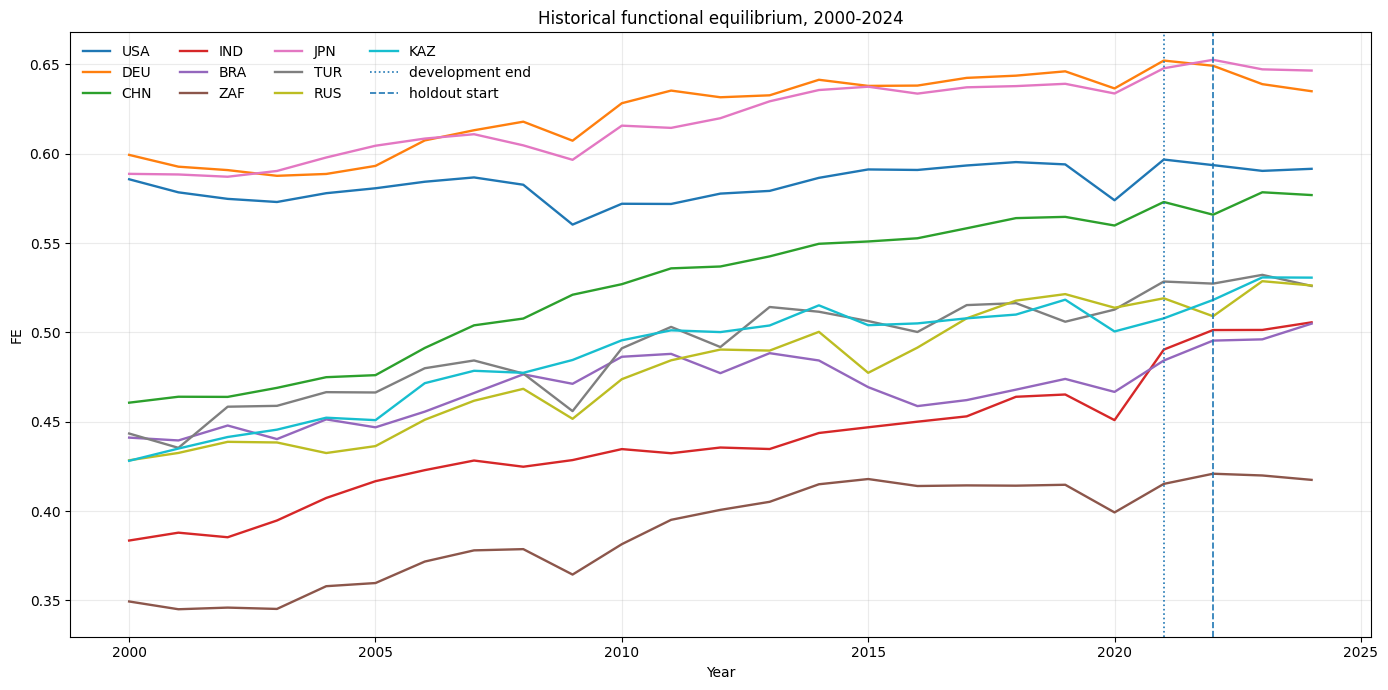

In [31]:
#@title 13.2. Историческое функциональное равновесие
historical_fe = state[["country", "year", "FE"]].copy()
fig, ax = plt.subplots(figsize=(14, 7))
for country in CFG.countries:
    group = historical_fe[historical_fe["country"] == country]
    ax.plot(group["year"], group["FE"], linewidth=1.7, label=country)
ax.axvline(2021, linestyle=":", linewidth=1.2, label="development end")
ax.axvline(2022, linestyle="--", linewidth=1.2, label="holdout start")
ax.set(title="Historical functional equilibrium, 2000-2024", xlabel="Year", ylabel="FE")
ax.grid(alpha=0.25)
ax.legend(ncol=4, frameon=False)
save_figure("01_historical_FE", historical_fe)

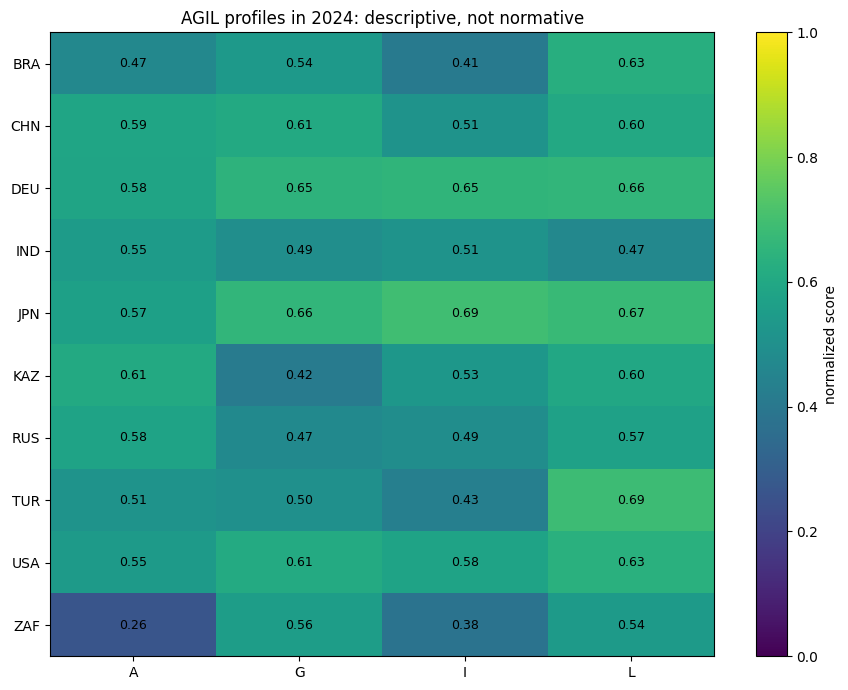

In [32]:
#@title 13.3. AGIL-профили 2024
profile_2024 = state[state["year"] == CFG.end_year][["country", *AGIL, "Reliability"]].set_index("country")
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(profile_2024[list(AGIL)].values, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(4), AGIL)
ax.set_yticks(range(len(profile_2024)), profile_2024.index)
for i in range(profile_2024.shape[0]):
    for j in range(4):
        ax.text(j, i, f"{profile_2024.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=ax, label="normalized score")
ax.set_title("AGIL profiles in 2024: descriptive, not normative")
save_figure("02_AGIL_profiles_2024", profile_2024.reset_index())

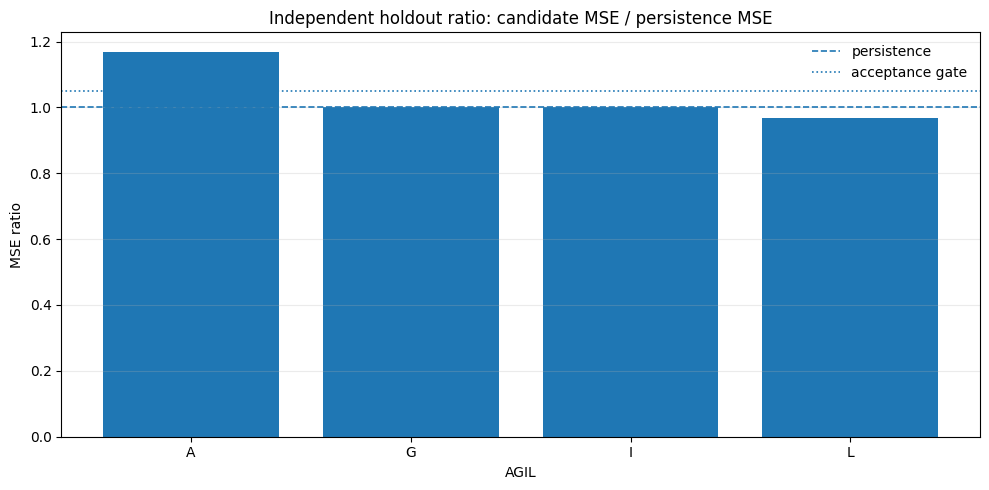

In [33]:
#@title 13.4. Development и holdout gates
model_gate_plot = holdout_validation[[
    "target", "development_candidate", "ratio", "holdout_passed", "production_candidate"
]].copy()
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(model_gate_plot))
ax.bar(positions, model_gate_plot["ratio"])
ax.axhline(1.0, linestyle="--", linewidth=1.2, label="persistence")
ax.axhline(CFG.holdout_ratio_gate, linestyle=":", linewidth=1.2, label="acceptance gate")
ax.set_xticks(positions, model_gate_plot["target"])
ax.set(title="Independent holdout ratio: candidate MSE / persistence MSE", xlabel="AGIL", ylabel="MSE ratio")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
save_figure("03_transition_model_gate", model_gate_plot)

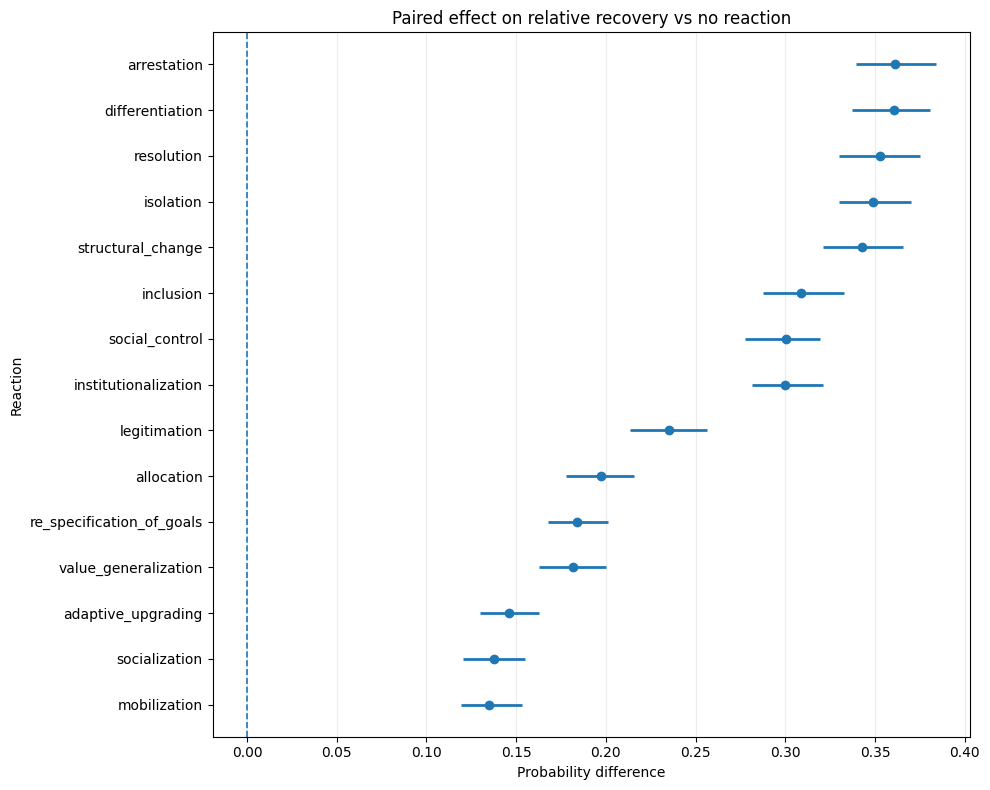

In [34]:
#@title 13.5. Парный эффект реакций на относительное восстановление
primary_ci = bootstrap_ci[bootstrap_ci["metric"] == "delta_relative_recovery"].sort_values("mean_effect")
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(primary_ci))
# Percentile bootstrap intervals need not contain the empirical mean in a skewed
# finite sample. Draw interval endpoints directly instead of passing negative
# asymmetric errors to matplotlib.errorbar.
ax.hlines(
    y=y,
    xmin=primary_ci["ci_low_95"],
    xmax=primary_ci["ci_high_95"],
    linewidth=2.0,
)
ax.plot(primary_ci["mean_effect"], y, "o")
ax.axvline(0.0, linestyle="--", linewidth=1.2)
ax.set_yticks(y, primary_ci["reaction"])
ax.set(title="Paired effect on relative recovery vs no reaction", xlabel="Probability difference", ylabel="Reaction")
ax.grid(axis="x", alpha=0.25)
save_figure("04_relative_recovery_effects", primary_ci)

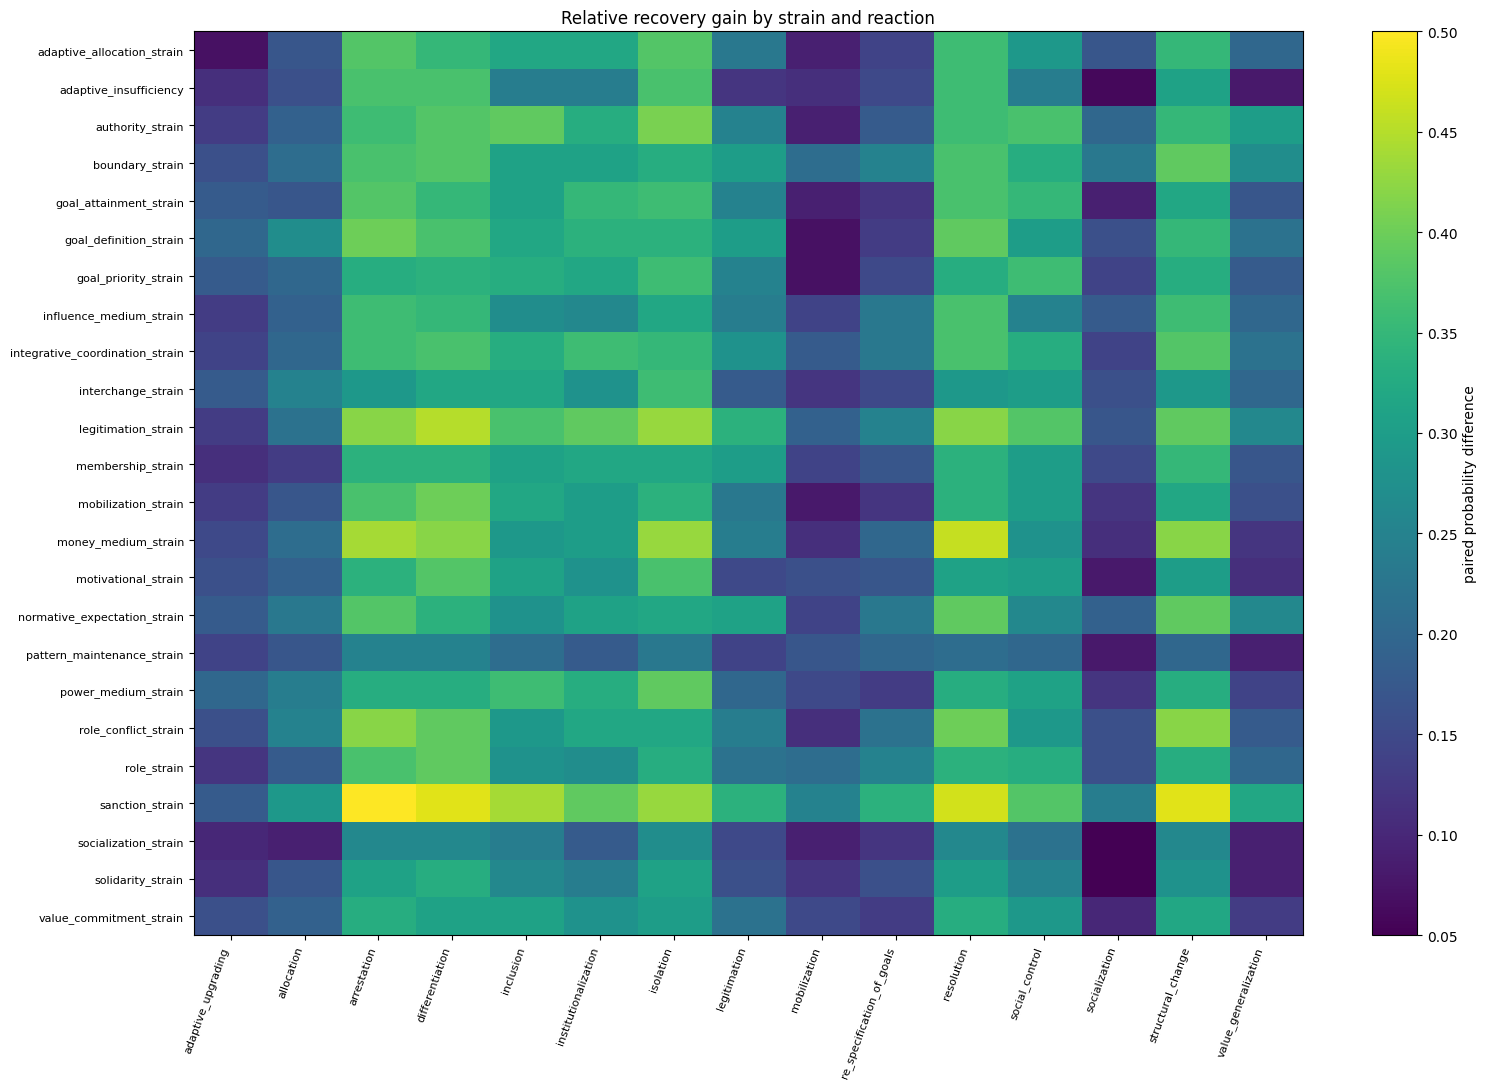

In [35]:
#@title 13.6. Heatmap strain × reaction: gain in relative recovery
strain_heatmap = strain_effects.pivot(index="scenario", columns="reaction", values="delta_relative_recovery")
fig, ax = plt.subplots(figsize=(16, 11))
image = ax.imshow(strain_heatmap.values, aspect="auto")
ax.set_xticks(range(len(strain_heatmap.columns)), strain_heatmap.columns, rotation=70, ha="right", fontsize=8)
ax.set_yticks(range(len(strain_heatmap.index)), strain_heatmap.index, fontsize=8)
fig.colorbar(image, ax=ax, label="paired probability difference")
ax.set_title("Relative recovery gain by strain and reaction")
save_figure("05_strain_reaction_effects", strain_heatmap.reset_index())

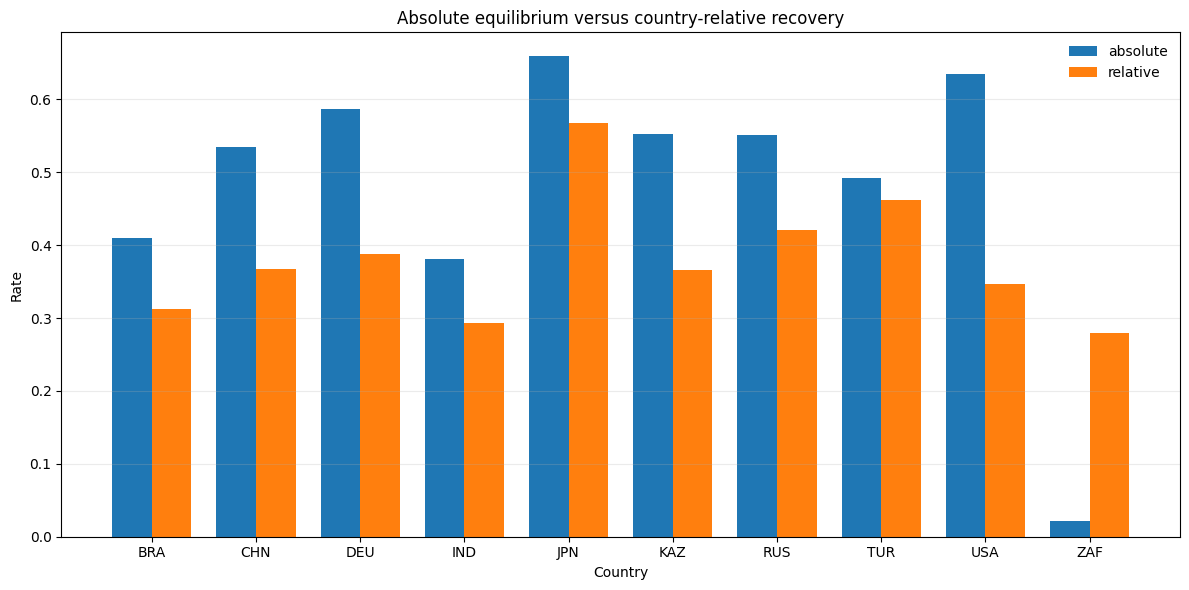

In [36]:
#@title 13.7. Абсолютное равновесие и относительное восстановление по странам
country_recovery = (
    simulation_seed_summary[simulation_seed_summary["reaction"] != CONTROL]
    .groupby("country", as_index=False)
    .agg(
        absolute_equilibrium_rate=("absolute_equilibrium", "mean"),
        relative_recovery_rate=("relative_recovery", "mean"),
    )
)
fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(country_recovery))
width = 0.38
ax.bar(positions - width / 2, country_recovery["absolute_equilibrium_rate"], width, label="absolute")
ax.bar(positions + width / 2, country_recovery["relative_recovery_rate"], width, label="relative")
ax.set_xticks(positions, country_recovery["country"])
ax.set(title="Absolute equilibrium versus country-relative recovery", xlabel="Country", ylabel="Rate")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
save_figure("06_absolute_vs_relative_country", country_recovery)

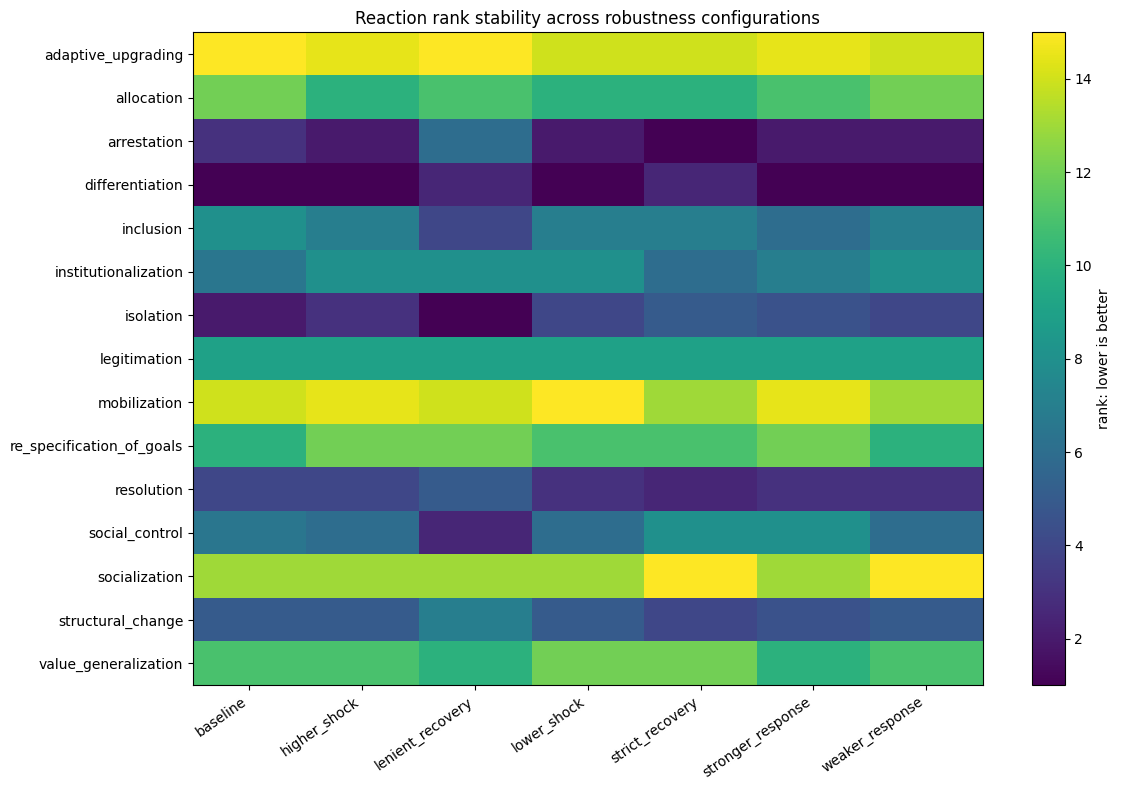

In [37]:
#@title 13.8. Устойчивость рангов реакций
rank_plot = robustness_results.pivot(index="reaction", columns="config", values="primary_rank")
fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(rank_plot.values, aspect="auto")
ax.set_xticks(range(len(rank_plot.columns)), rank_plot.columns, rotation=35, ha="right")
ax.set_yticks(range(len(rank_plot.index)), rank_plot.index)
fig.colorbar(image, ax=ax, label="rank: lower is better")
ax.set_title("Reaction rank stability across robustness configurations")
save_figure("07_robustness_ranks", rank_plot.reset_index())

PROGRESS.stage_log.append({
    "stage": "publication figures completed",
    "completed_units": PROGRESS.completed,
})

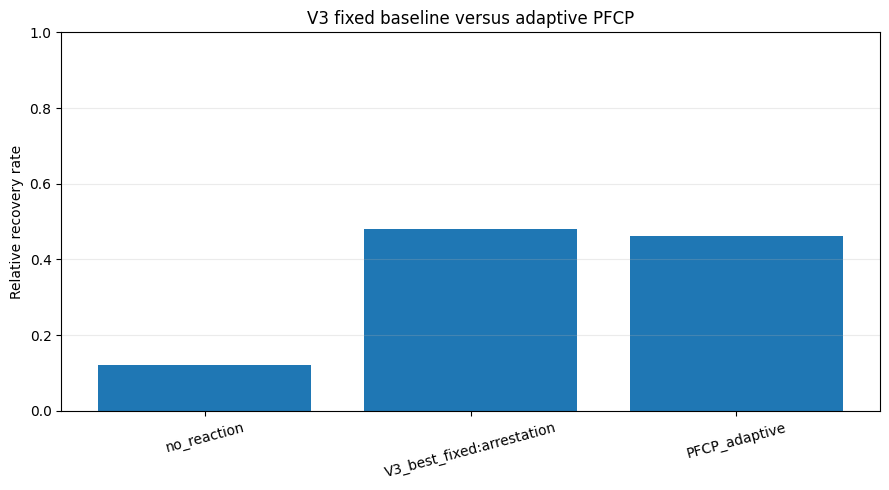

In [38]:
#@title 13.9. PFCP и V3 baseline: относительное восстановление
comparison_plot = pd.DataFrame([
    {
        "architecture": "no_reaction",
        "relative_recovery_rate": simulation_seed_summary.loc[
            simulation_seed_summary["reaction"] == CONTROL,
            "relative_recovery",
        ].mean(),
    },
    {
        "architecture": f"V3_best_fixed:{best_v3_reaction}",
        "relative_recovery_rate": simulation_seed_summary.loc[
            simulation_seed_summary["reaction"] == best_v3_reaction,
            "relative_recovery",
        ].mean(),
    },
    {
        "architecture": "PFCP_adaptive",
        "relative_recovery_rate": pfcp_seed_summary[
            "relative_recovery"
        ].mean(),
    },
])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    comparison_plot["architecture"],
    comparison_plot["relative_recovery_rate"],
)
ax.set_ylim(0, 1)
ax.set_ylabel("Relative recovery rate")
ax.set_title("V3 fixed baseline versus adaptive PFCP")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
save_figure("08_pfcp_vs_v3_recovery", comparison_plot)


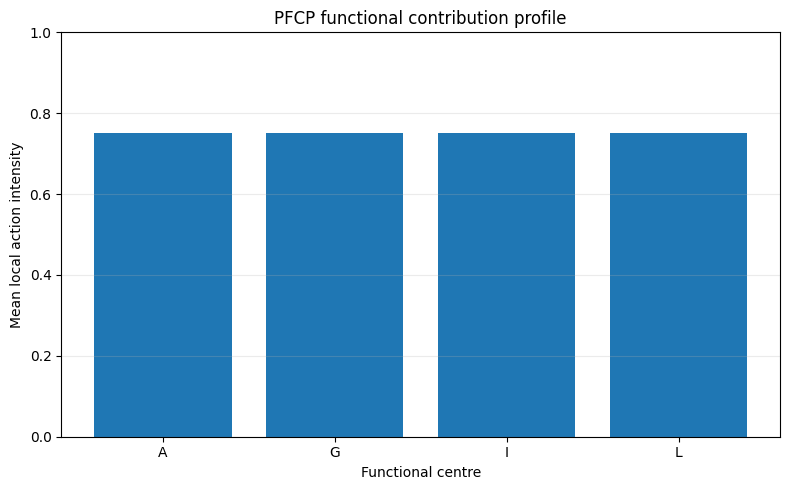

In [39]:
#@title 13.10. Функциональный профиль действий PFCP
action_profile = (
    pfcp_seed_summary[[
        "mean_action_A", "mean_action_G",
        "mean_action_I", "mean_action_L",
    ]]
    .mean()
    .rename(lambda name: name.replace("mean_action_", ""))
    .rename_axis("AGIL")
    .reset_index(name="mean_action")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(action_profile["AGIL"], action_profile["mean_action"])
ax.set_ylim(0, 1)
ax.set_xlabel("Functional centre")
ax.set_ylabel("Mean local action intensity")
ax.set_title("PFCP functional contribution profile")
ax.grid(axis="y", alpha=0.25)
save_figure("09_pfcp_action_profile", action_profile)


## 14. Компактный экспорт

Создаются пять Excel-книг. Тяжёлые seed-level таблицы сохраняются только в сжатом `CSV.GZ`; Excel содержит агрегаты, необходимые для анализа и статьи.

In [40]:
#@title 14.1. Excel helpers

def add_readme(
    writer: pd.ExcelWriter,
    title: str,
    description: str,
    sheets: Sequence[Tuple[str, str]],
) -> None:
    workbook = writer.book
    worksheet = workbook.add_worksheet("README")
    writer.sheets["README"] = worksheet

    title_format = workbook.add_format({
        "bold": True, "font_size": 16, "font_color": "white", "bg_color": "#1F4E78"
    })
    header_format = workbook.add_format({
        "bold": True, "font_color": "white", "bg_color": "#5B9BD5"
    })
    wrap_format = workbook.add_format({"text_wrap": True, "valign": "top"})
    link_format = workbook.add_format({"font_color": "blue", "underline": 1})

    worksheet.set_column("A:A", 34)
    worksheet.set_column("B:B", 95)
    worksheet.merge_range("A1:B1", title, title_format)
    worksheet.write("A3", "Назначение", header_format)
    worksheet.write("B3", description, wrap_format)
    worksheet.write("A5", "Лист", header_format)
    worksheet.write("B5", "Содержание", header_format)
    for row_number, (sheet_name, explanation) in enumerate(sheets, start=5):
        worksheet.write_url(
            row_number, 0, f"internal:'{sheet_name}'!A1", link_format, string=sheet_name
        )
        worksheet.write(row_number, 1, explanation, wrap_format)
    worksheet.freeze_panes(5, 0)


def format_workbook(writer: pd.ExcelWriter) -> None:
    workbook = writer.book
    header_format = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#4472C4",
        "border": 1,
        "text_wrap": True,
        "align": "center",
        "valign": "vcenter",
    })
    for name, worksheet in writer.sheets.items():
        if name == "README":
            continue
        worksheet.freeze_panes(1, 0)
        worksheet.set_row(0, 32, header_format)
        worksheet.set_column(0, min(3, worksheet.dim_colmax), 20)
        if worksheet.dim_colmax > 3:
            worksheet.set_column(4, worksheet.dim_colmax, 16)
        if worksheet.dim_rowmax > 0 and worksheet.dim_colmax >= 0:
            worksheet.autofilter(0, 0, worksheet.dim_rowmax, worksheet.dim_colmax)

In [41]:
#@title 14.2. Сжатые таблицы и пять Excel-книг
# 1 unit: compressed tables
compressed_tables = {
    "simulation_seed_summary": simulation_seed_summary,
    "treatment_seed_effects": treatment_seed_effects,
    "robustness_seed_effects": robustness_seed_effects,
    "pfcp_seed_summary": pfcp_seed_summary,
    "pfcp_effects": pfcp_effects,
}
for name, table in compressed_tables.items():
    table.to_csv(
        OUT / "tables_csv" / f"{name}.csv.gz",
        index=False,
        compression="gzip",
    )
PROGRESS.advance(1, "compressed seed-level tables")

# 2. Master index
with pd.ExcelWriter(OUT / "00_Parsons_V4_Master_Index.xlsx", engine="xlsxwriter") as writer:
    configuration = pd.DataFrame([
        {"parameter": key, "value": str(value)} for key, value in asdict(CFG).items()
    ])
    formulas = pd.DataFrame([
        {"construct": "Functional equilibrium", "formula": "FE=(A*G*I*L)^(1/4)", "meaning": "Geometric balance of four necessary functions"},
        {"construct": "Bottleneck", "formula": "B=min(A,G,I,L)", "meaning": "Weakest functional component"},
        {"construct": "Coverage", "formula": "C_i=observed_i/(countries*years)", "meaning": "Indicator included at C_i>=0.70"},
        {"construct": "Relative recovery", "formula": "FE>=FE0-e_FE; B>=B0-e_B; S<=S0+e_S", "meaning": "Recovery relative to own pre-shock baseline"},
        {"construct": "Paired effect", "formula": "Delta Y=Y_reaction-Y_no_reaction", "meaning": "Common-random-number treatment effect"},
        {"construct": "PFCP factorization", "formula": "Qcoord=sum Q_f + lambda sum psi_fg", "meaning": "Partial decentralization with coordination graph"},
    ])
    file_map = pd.DataFrame([
        {"file": "01_Parsons_V4_Data_Measurement.xlsx", "content": "Input, coverage, preprocessing, AGIL"},
        {"file": "02_Parsons_V4_Model_Validation.xlsx", "content": "Development folds, holdout gates, production model"},
        {"file": "03_Parsons_V4_Simulation_Aggregates.xlsx", "content": "Compact V3 baseline and PFCP comparison aggregates"},
        {"file": "04_Parsons_V4_Statistics_Figures.xlsx", "content": "Inference, robustness and figure source data"},
        {"file": "tables_csv/*.csv.gz", "content": "Compressed seed-level audit tables"},
    ])
    configuration.to_excel(writer, sheet_name="Configuration", index=False)
    formulas.to_excel(writer, sheet_name="Formulas", index=False)
    file_map.to_excel(writer, sheet_name="File_Map", index=False)
    data_quality.to_excel(writer, sheet_name="Data_Quality", index=False)
    thresholds_table.to_excel(writer, sheet_name="Thresholds", index=False)
    add_readme(writer, "Parsons V4 - Master index", "Навигация, параметры и формулы production-ready эксперимента.", [
        ("Configuration", "Фиксированная конфигурация."),
        ("Formulas", "Основные вычислительные формулы."),
        ("File_Map", "Карта выходных файлов."),
        ("Data_Quality", "Аудит исходной панели."),
        ("Thresholds", "Абсолютные пороги и относительные допуски."),
    ])
    format_workbook(writer)
PROGRESS.advance(1, "Excel 00 master index")

# 3. Data and measurement
with pd.ExcelWriter(OUT / "01_Parsons_V4_Data_Measurement.xlsx", engine="xlsxwriter") as writer:
    raw.to_excel(writer, sheet_name="Raw_2000_2024", index=False)
    coverage.to_excel(writer, sheet_name="Indicator_Coverage", index=False)
    coverage[~coverage["included"]].to_excel(writer, sheet_name="Excluded_Indicators", index=False)
    train_parameters.to_excel(writer, sheet_name="Train_Parameters", index=False)
    imputation_audit.to_excel(writer, sheet_name="Imputation_Audit", index=False)
    panel.to_excel(writer, sheet_name="Processed_Long", index=False)
    agil_long.to_excel(writer, sheet_name="AGIL_Long", index=False)
    state.to_excel(writer, sheet_name="System_States", index=False)
    measurement_diagnostics.to_excel(writer, sheet_name="Measurement_Diagnostics", index=False)
    sources = raw[["indicator_code", "indicator_name", "source_url"]].drop_duplicates()
    sources.to_excel(writer, sheet_name="Sources", index=False)
    add_readme(writer, "Parsons V4 - Data and measurement", "Реальная панель, 70% coverage gate, train-only preprocessing и AGIL.", [
        ("Raw_2000_2024", "Исходная реальная панель."),
        ("Indicator_Coverage", "Покрытие и решение о включении."),
        ("Excluded_Indicators", "Исключённые показатели."),
        ("Train_Parameters", "Train-only медианы и IQR."),
        ("Imputation_Audit", "Аудит импутации."),
        ("Processed_Long", "Обработанная панель."),
        ("AGIL_Long", "Индексы функций."),
        ("System_States", "Состояния country-year."),
        ("Measurement_Diagnostics", "Диагностика измерения."),
        ("Sources", "Источники индикаторов."),
    ])
    format_workbook(writer)
PROGRESS.advance(1, "Excel 01 data measurement")

# 4. Model validation
with pd.ExcelWriter(OUT / "02_Parsons_V4_Model_Validation.xlsx", engine="xlsxwriter") as writer:
    development_folds.to_excel(writer, sheet_name="Development_Folds", index=False)
    development_summary.to_excel(writer, sheet_name="Development_Summary", index=False)
    selected_development.to_excel(writer, sheet_name="Development_Selected", index=False)
    holdout_validation.to_excel(writer, sheet_name="Holdout_Acceptance", index=False)
    final_model_selection.to_excel(writer, sheet_name="Production_Selection", index=False)
    production_model_parameters.to_excel(writer, sheet_name="Production_Parameters", index=False)
    add_readme(writer, "Parsons V4 - Model validation", "Rolling-origin development, independent holdout and automatic safety fallback.", [
        ("Development_Folds", "Результат каждого кандидата в каждом fold."),
        ("Development_Summary", "Агрегированное качество кандидатов."),
        ("Development_Selected", "Кандидат после development gate."),
        ("Holdout_Acceptance", "Независимая проверка 2022-2024."),
        ("Production_Selection", "Итоговая безопасная модель по каждой функции."),
        ("Production_Parameters", "Параметры refit-моделей."),
    ])
    format_workbook(writer)
PROGRESS.advance(1, "Excel 02 model validation")

# Publication-size trajectory summaries: no country×scenario full cube in Excel.
v3_trajectory_publication = (
    trajectory_aggregates.groupby(["reaction", "step"], as_index=False)
    .agg(
        FE_mean=("FE_mean", "mean"),
        Strain_mean=("Strain_mean", "mean"),
        Bottleneck_mean=("Bottleneck_mean", "mean"),
        Institutionalization_mean=("Institutionalization_mean", "mean"),
    )
)
pfcp_trajectory_publication = (
    pfcp_trajectory_aggregates.groupby("step", as_index=False)
    .agg(
        FE_mean=("FE_mean", "mean"),
        FE_sd=("FE_mean", "std"),
        Strain_mean=("Strain_mean", "mean"),
        Bottleneck_mean=("Bottleneck_mean", "mean"),
        Institutionalization_mean=("Institutionalization_mean", "mean"),
    )
)

# 5. Simulation aggregates
simulation_by_reaction = reaction_outcomes.merge(reaction_effects_point, on="reaction", how="left")
simulation_by_country = (
    treatment_seed_effects.groupby(["country", "reaction"], as_index=False)
    .agg(
        delta_survival=("delta_survival", "mean"),
        delta_absolute_equilibrium=("delta_absolute_equilibrium", "mean"),
        delta_relative_recovery=("delta_relative_recovery", "mean"),
        delta_final_FE=("delta_final_FE", "mean"),
        delta_cumulative_strain=("delta_cumulative_strain", "mean"),
    )
)
with pd.ExcelWriter(OUT / "03_Parsons_V4_Simulation_Aggregates.xlsx", engine="xlsxwriter") as writer:
    scenario_catalog.to_excel(writer, sheet_name="Strain_Catalog", index=False)
    reaction_catalog.to_excel(writer, sheet_name="Reaction_Catalog", index=False)
    robustness_catalog.to_excel(writer, sheet_name="Robustness_Catalog", index=False)
    simulation_by_reaction.to_excel(writer, sheet_name="Reaction_Aggregates", index=False)
    simulation_by_country.to_excel(writer, sheet_name="Country_Reaction", index=False)
    strain_effects.to_excel(writer, sheet_name="Strain_Reaction", index=False)
    v3_trajectory_publication.to_excel(writer, sheet_name="V3_Trajectory_Compact", index=False)
    pfcp_trajectory_publication.to_excel(writer, sheet_name="PFCP_Trajectory_Compact", index=False)
    pfcp_outcomes.to_excel(writer, sheet_name="PFCP_Comparison", index=False)
    pfcp_by_country.to_excel(writer, sheet_name="PFCP_Country", index=False)
    pfcp_by_strain.to_excel(writer, sheet_name="PFCP_Strain", index=False)
    pfcp_policy_summary.to_excel(writer, sheet_name="PFCP_Policy_Audit", index=False)
    pfcp_training_curve.to_excel(writer, sheet_name="PFCP_Training", index=False)
    add_readme(writer, "Parsons V4 - Simulation aggregates", "Компактные агрегаты; полные seed-level результаты находятся в CSV.GZ.", [
        ("Strain_Catalog", "24 нормированных strain-профиля."),
        ("Reaction_Catalog", "15 реакций и контроль."),
        ("Robustness_Catalog", "Параметрические проверки."),
        ("Reaction_Aggregates", "Результаты и парные эффекты по реакциям."),
        ("Country_Reaction", "Парные эффекты по странам."),
        ("Strain_Reaction", "Парные эффекты по strain."),
        ("V3_Trajectory_Compact", "V3 baseline: агрегаты по reaction × step."),
        ("PFCP_Trajectory_Compact", "PFCP: агрегаты по step."),
        ("PFCP_Comparison", "PFCP против контроля и лучшей fixed reaction V3."),
        ("PFCP_Country", "PFCP effects по странам."),
        ("PFCP_Strain", "PFCP effects по strain."),
        ("PFCP_Policy_Audit", "Интерпретируемый аудит локальных Q-policy."),
        ("PFCP_Training", "Сглаженная кривая обучения."),
    ])
    format_workbook(writer)
PROGRESS.advance(1, "Excel 03 simulation aggregates")

# 6. Statistics and figures
with pd.ExcelWriter(OUT / "04_Parsons_V4_Statistics_Figures.xlsx", engine="xlsxwriter") as writer:
    bootstrap_ci.to_excel(writer, sheet_name="Bootstrap_CI", index=False)
    wilcoxon_vs_control.to_excel(writer, sheet_name="Wilcoxon_vs_Control", index=False)
    friedman_table.to_excel(writer, sheet_name="Friedman", index=False)
    pfcp_outcomes.to_excel(writer, sheet_name="PFCP_Outcome", index=False)
    pfcp_vs_v3[[c for c in pfcp_vs_v3.columns if c.startswith("pfcp_minus_v3_") or c in ["country","scenario","seed"]]].to_excel(writer, sheet_name="PFCP_vs_V3_Paired", index=False)
    robustness_results.to_excel(writer, sheet_name="Robustness_Results", index=False)
    rank_stability.to_excel(writer, sheet_name="Rank_Stability", index=False)
    absolute_relative_country.to_excel(writer, sheet_name="Absolute_Relative", index=False)
    figure_sheets = []
    for index, (name, table) in enumerate(FIGURE_DATA.items(), start=1):
        sheet_name = f"Fig{index:02d}_{name[:20]}"
        table.to_excel(writer, sheet_name=sheet_name, index=False)
        figure_sheets.append((sheet_name, f"Точная таблица-источник рисунка {name}."))
    add_readme(writer, "Parsons V4 - Statistics and figures", "Парная статистика, robustness и таблицы-источники всех рисунков.", [
        ("Bootstrap_CI", "Bootstrap 95% CI парных эффектов."),
        ("Wilcoxon_vs_Control", "Wilcoxon и BH-коррекция."),
        ("Friedman", "Общее сравнение 15 реакций."),
        ("Robustness_Results", "Эффекты по конфигурациям."),
        ("Rank_Stability", "Устойчивость рангов."),
        ("Absolute_Relative", "Абсолютное и относительное восстановление."),
        *figure_sheets,
    ])
    format_workbook(writer)
PROGRESS.advance(1, "Excel 04 statistics figures")

# 7. GitHub support files
requirements_text = "\n".join([
    "pandas>=2.0",
    "numpy>=1.26",
    "scipy>=1.11",
    "scikit-learn>=1.4",
    "statsmodels>=0.14",
    "matplotlib>=3.8",
    "xlsxwriter>=3.2",
    "tqdm>=4.66",
    "nbformat>=5.10",
]) + "\n"
(OUT / "github" / "requirements.txt").write_text(requirements_text, encoding="utf-8")
readme_text = f"""# Parsons Political System Experiment V3

- Data mode: real_only
- Synthetic fallback: false
- Window: {CFG.start_year}-{CFG.end_year}
- Coverage threshold: {CFG.coverage_threshold:.0%}
- Included indicators: {len(included_codes)}
- Excluded indicators: {len(excluded_codes)}
- Main seeds: {CFG.n_seeds}
- Robustness seeds: {CFG.robustness_seeds}
- Strain classes: {len(STRAIN_CLASSES)}
- Reactions: {len(REACTIONS)} plus no_reaction control

The ontology is grounded in Talcott Parsons. Mathematical and statistical
procedures are computational operationalizations and are not attributed to
Parsons as his own equations.
"""
(OUT / "README.md").write_text(readme_text, encoding="utf-8")
(OUT / "github" / "README.md").write_text(readme_text, encoding="utf-8")
PROGRESS.advance(1, "GitHub support files")

# 8. Manifest and archive
manifest = {
    "experiment": "Parsons Political System Computational Experiment",
    "version": "4.0-coordination-real",
    "data_mode": "real_only",
    "synthetic_fallback": False,
    "config": asdict(CFG),
    "ontology_hash": ONTOLOGY_HASH,
    "data_file": DATA_PATH.name,
    "data_sha256": DATA_SHA256,
    "included_indicators": included_codes,
    "excluded_indicators": excluded_codes,
    "production_model_selection": final_model_selection.to_dict(orient="records"),
    "adaptive_architecture": "PFCP factorized partially observable coordination process",
    "baseline_architecture": "V3 fixed reactions plus no_reaction",
    "pfcp_training_episodes": CFG.pfcp_training_episodes,
    "pfcp_best_v3_comparator": best_v3_reaction,
    "pfcp_outcome": pfcp_outcomes.to_dict(orient="records"),
    "progress_expected_units": PROGRESS.total,
    "progress_completed_units": PROGRESS.total,
    "pipeline_stage_log": PROGRESS.stage_log + [{
        "stage": "exports and archive completed",
        "completed_units": PROGRESS.total,
    }],
    "files": [],
}
for item in sorted(OUT.rglob("*")):
    if item.is_file() and item.name != "manifest.json":
        manifest["files"].append({
            "path": str(item.relative_to(OUT)),
            "bytes": int(item.stat().st_size),
            "sha256": hashlib.sha256(item.read_bytes()).hexdigest(),
        })
(OUT / "manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)
PROGRESS.advance(1, "manifest written")

archive_path = shutil.make_archive(
    str(OUT.parent / "Parsons_Experiment_V4_PRODUCTION_outputs"),
    "zip",
    root_dir=OUT,
)
PROGRESS.advance(1, "archive created")
PROGRESS.stage_log.append({
    "stage": "exports and archive completed",
    "completed_units": PROGRESS.completed,
})
PROGRESS.close()

print("Output directory:", OUT.resolve())
print("Archive:", Path(archive_path).resolve())
print("Archive size MB:", round(Path(archive_path).stat().st_size / 1024**2, 2))

Output directory: /content/parsons_v4_outputs
Archive: /content/Parsons_Experiment_V4_PRODUCTION_outputs.zip
Archive size MB: 9.83


In [42]:
#@title 14.3. Скачивание архива в Google Colab
archive_file = Path(archive_path)
if IN_COLAB:
    from google.colab import files
    files.download(str(archive_file))
else:
    print("Outside Colab. Archive:", archive_file.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Интерпретационное ограничение V4

PFCP не утверждает, что парсонсовские функции являются самостоятельными
психологическими или юридическими субъектами. Они представлены как
функциональные центры частичного наблюдения и вклада.

Сравнение PFCP с V3 отвечает ограниченному вопросу:

> даёт ли адаптивная функциональная координация прирост относительно
> заранее фиксированных системных реакций при одинаковом strain,
> одинаковой исторической переходной модели и common random numbers?

Положительный результат не доказывает теорию Парсонса, но показывает
вычислительную продуктивность её близкой операционализации.
